# Machine Learning Modeling, Tuning, and Final Evaluation for Music Genre Classification

**Continuation of:** EDA and Preprocessing notebook (`features_3_sec_cleaned`)

**Task:** Multiclass music genre classification (10 classes)

**Models:** Logistic Regression (Linear Classifier), Random Forest, Neural Network (MLPClassifier)

**Protocol:**
- Official train/test split from Notebook 1 is preserved.
- **Locked test set** (`X_test_tree`, `y_test`) is used **once** for final evaluation only.
- A **validation set** (25% of original training data) is created for model selection and tuning.
- **StandardScaler** is refit on the new training split only (no use of pre-saved scaled files for modeling).


## PART 1 — Setup and Library Imports


### Cell 1 — Import Libraries


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
sns.set_palette("husl")

BASE_DIR = Path(r"path")
OUTPUT_DIR = BASE_DIR / "modeling_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries imported. Random state:", RANDOM_STATE)
print("Base directory:", BASE_DIR)
print("Output directory:", OUTPUT_DIR)

## PART 2 — Load Files Generated by the First Notebook


### Cell 2 — Load All Required Files


In [9]:
# Paths from Notebook 1
CLEANED_PATH = BASE_DIR / "features_3_sec_cleaned.csv"
X_TRAIN_TREE_PATH = BASE_DIR / "X_train_tree.csv"
X_TEST_TREE_PATH = BASE_DIR / "X_test_tree.csv"
Y_TRAIN_PATH = BASE_DIR / "y_train.csv"
Y_TEST_PATH = BASE_DIR / "y_test.csv"
LABEL_MAP_PATH = BASE_DIR / "label_mapping.csv"

# Optional reference only (not used for modeling pipeline)
X_TRAIN_SCALED_REF_PATH = BASE_DIR / "X_train_scaled.csv"
X_TEST_SCALED_REF_PATH = BASE_DIR / "X_test_scaled.csv"

cleaned_df = pd.read_csv(CLEANED_PATH)
X_train_full_tree = pd.read_csv(X_TRAIN_TREE_PATH)
X_test_tree_locked = pd.read_csv(X_TEST_TREE_PATH)
y_train_full = pd.read_csv(Y_TRAIN_PATH)["label_encoded"]
y_test_locked = pd.read_csv(Y_TEST_PATH)["label_encoded"]
class_mapping_df = pd.read_csv(LABEL_MAP_PATH).sort_values("encoded_label").reset_index(drop=True)

# Reference scaled files (comparison only)
X_train_scaled_ref = pd.read_csv(X_TRAIN_SCALED_REF_PATH)
X_test_scaled_ref = pd.read_csv(X_TEST_SCALED_REF_PATH)

print("Loaded files successfully.")
print(f"  cleaned_df:              {cleaned_df.shape}")
print(f"  X_train_full_tree:       {X_train_full_tree.shape}")
print(f"  X_test_tree_locked:      {X_test_tree_locked.shape}")
print(f"  y_train_full:            {y_train_full.shape}")
print(f"  y_test_locked:           {y_test_locked.shape}")
print(f"  class_mapping_df:        {class_mapping_df.shape}")
print(f"  X_train_scaled_ref:      {X_train_scaled_ref.shape} (reference only)")
print(f"  X_test_scaled_ref:       {X_test_scaled_ref.shape} (reference only)")


Loaded files successfully.
  cleaned_df:              (9990, 60)
  X_train_full_tree:       (7992, 57)
  X_test_tree_locked:      (1998, 57)
  y_train_full:            (7992,)
  y_test_locked:           (1998,)
  class_mapping_df:        (10, 2)
  X_train_scaled_ref:      (7992, 57) (reference only)
  X_test_scaled_ref:       (1998, 57) (reference only)


### Cell 3 — File Consistency Checks


In [10]:
def validate_loaded_data():
  """Raise clear errors if loaded artifacts are inconsistent."""
  errors = []

  if len(X_train_full_tree) != len(y_train_full):
    errors.append("Row count mismatch: X_train_full_tree vs y_train_full")
  if len(X_test_tree_locked) != len(y_test_locked):
    errors.append("Row count mismatch: X_test_tree_locked vs y_test_locked")
  if list(X_train_full_tree.columns) != list(X_test_tree_locked.columns):
    errors.append("Feature column mismatch between train and locked test")
  if len(class_mapping_df) != 10:
    errors.append(f"Expected 10 classes in label_mapping, got {{len(class_mapping_df)}}")
  if X_train_full_tree.isnull().sum().sum() > 0:
    errors.append("Missing values in X_train_full_tree")
  if X_test_tree_locked.isnull().sum().sum() > 0:
    errors.append("Missing values in X_test_tree_locked")
  if not all(X_train_full_tree.dtypes.apply(lambda x: np.issubdtype(x, np.number))):
    errors.append("Non-numeric columns in X_train_full_tree")

  if errors:
    raise ValueError("Data validation failed:\n" + "\n".join(f"  - {{e}}" for e in errors))

  print("All consistency checks passed.")
  print("Locked test: shape and columns verified only (no feature distribution analysis).")

validate_loaded_data()

FEATURE_COLUMNS = list(X_train_full_tree.columns)
CLASS_NAMES = class_mapping_df.sort_values("encoded_label")["genre_name"].tolist()
ENCODED_TO_NAME = dict(zip(class_mapping_df["encoded_label"], class_mapping_df["genre_name"]))


All consistency checks passed.
Locked test: shape and columns verified only (no feature distribution analysis).


## PART 3 — Dataset and Split Consistency Checks


### Cell 4 — Dataset Overview and Class Mapping


In [11]:
print("Cleaned dataset shape:", cleaned_df.shape)
print("\nExisting official train/test split from Notebook 1:")
print(f"  Training features: {{X_train_full_tree.shape}}")
print(f"  Locked test features: {{X_test_tree_locked.shape}}")
print(f"  Training labels:     {{y_train_full.shape}}")
print(f"  Locked test labels:  {{y_test_locked.shape}}")

print("\nClass mapping:")
display(class_mapping_df)
print(f"Number of classes: {{len(class_mapping_df)}}")

# Decode labels for reporting only
y_train_genres = y_train_full.map(ENCODED_TO_NAME)
y_test_genres_locked = y_test_locked.map(ENCODED_TO_NAME)


Cleaned dataset shape: (9990, 60)

Existing official train/test split from Notebook 1:
  Training features: {X_train_full_tree.shape}
  Locked test features: {X_test_tree_locked.shape}
  Training labels:     {y_train_full.shape}
  Locked test labels:  {y_test_locked.shape}

Class mapping:


,encoded_label,genre_name
0,0,blues
1,1,classical
2,2,country
3,3,disco
4,4,hiphop
5,5,jazz
6,6,metal
7,7,pop
8,8,reggae
9,9,rock


Number of classes: {len(class_mapping_df)}


### Cell 5 — Class Distribution (Full, Train, Locked Test)


Class proportion comparison (%):


,full_cleaned_pct,original_train_pct,locked_test_pct
blues,10.01,10.01,10.01
classical,9.99,10.00,9.96
country,9.98,9.98,9.96
disco,10.00,10.00,10.01
hiphop,9.99,9.98,10.01
jazz,10.01,10.01,10.01
metal,10.01,10.01,10.01
pop,10.01,10.01,10.01
reggae,10.01,10.01,10.01
rock,9.99,9.98,10.01


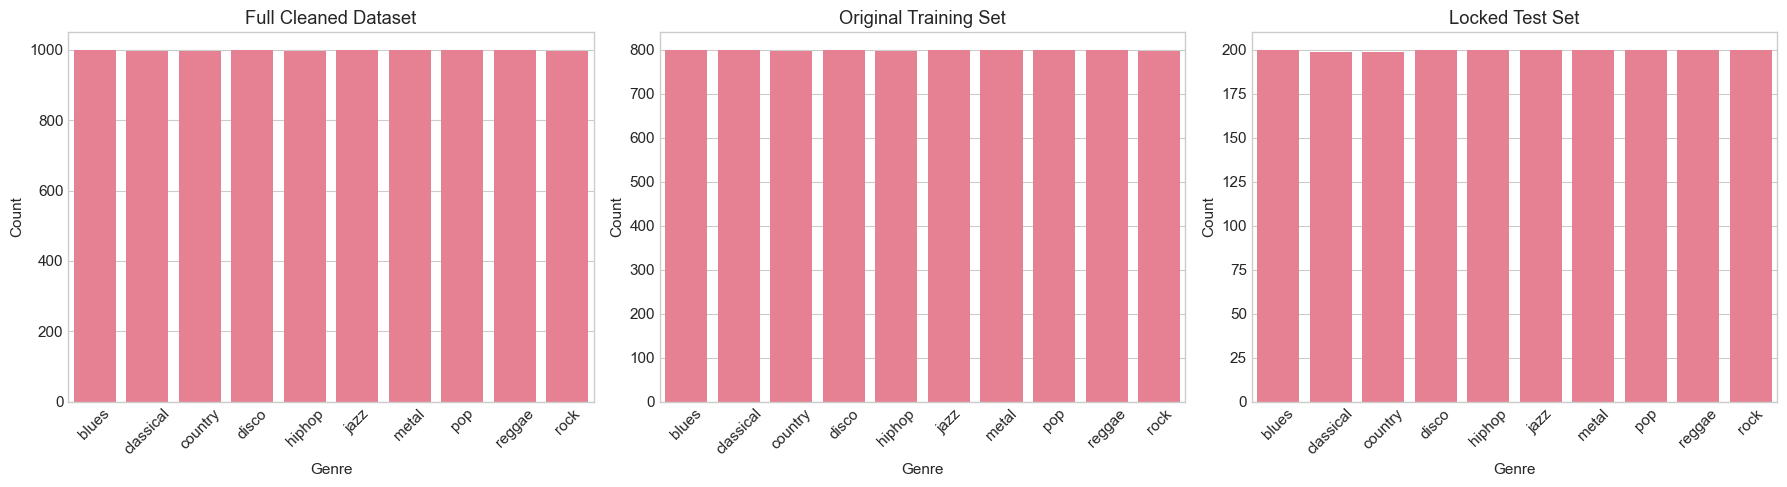


Note: The locked test set is used only for stratification confirmation at this stage
and will NOT be used for modeling decisions, tuning, or preprocessing.


In [12]:
def class_distribution_table(labels, name):
    counts = labels.value_counts().sort_index()
    pct = (100 * counts / counts.sum()).round(2)
    
    return pd.DataFrame(
        {"count": counts, "percentage": pct},
        index=counts.index
    ).assign(split=name)


dist_full = class_distribution_table(cleaned_df["label"], "full_cleaned")
dist_train = class_distribution_table(y_train_genres, "original_train")
dist_test = class_distribution_table(y_test_genres_locked, "locked_test")

prop_compare = pd.DataFrame({
    "full_cleaned_pct": (100 * cleaned_df["label"].value_counts(normalize=True)).sort_index().round(2),
    "original_train_pct": (100 * y_train_genres.value_counts(normalize=True)).sort_index().round(2),
    "locked_test_pct": (100 * y_test_genres_locked.value_counts(normalize=True)).sort_index().round(2),
})

print("Class proportion comparison (%):")
display(prop_compare)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(
    axes,
    [cleaned_df["label"], y_train_genres, y_test_genres_locked],
    ["Full Cleaned Dataset", "Original Training Set", "Locked Test Set"],
):
    order = sorted(data.unique())
    counts = data.value_counts().reindex(order)
    
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Genre")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nNote: The locked test set is used only for stratification confirmation at this stage")
print("and will NOT be used for modeling decisions, tuning, or preprocessing.")

## PART 4 — Create Validation Set from Existing Training Data


### Cell 6 — Train / Validation Split (75% / 25% of Original Training)


In [13]:
X_train_tree, X_val_tree, y_train, y_val = train_test_split(
    X_train_full_tree,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

# Locked test remains unchanged
X_test_tree = X_test_tree_locked.copy()
y_test = y_test_locked.copy()

print("Shapes after validation split:")
print(f"  X_train_tree:         {{X_train_tree.shape}}  (~60% of full data)")
print(f"  X_val_tree:           {{X_val_tree.shape}}    (~20% of full data)")
print(f"  X_test_tree_locked:   {{X_test_tree.shape}}   (~20% of full data)")
print(f"  y_train:              {{y_train.shape}}")
print(f"  y_val:                {{y_val.shape}}")
print(f"  y_test_locked:        {{y_test.shape}}")

y_train_genres_split = y_train.map(ENCODED_TO_NAME)
y_val_genres = y_val.map(ENCODED_TO_NAME)


Shapes after validation split:
  X_train_tree:         {X_train_tree.shape}  (~60% of full data)
  X_val_tree:           {X_val_tree.shape}    (~20% of full data)
  X_test_tree_locked:   {X_test_tree.shape}   (~20% of full data)
  y_train:              {y_train.shape}
  y_val:                {y_val.shape}
  y_test_locked:        {y_test.shape}


### Cell 7 — Class Distribution: Train, Validation, Locked Test


Class proportions across train / validation / locked test (%):


,train_pct,validation_pct,locked_test_pct
label_encoded,,,
blues,10.01,10.01,10.01
classical,9.99,10.01,9.96
country,9.99,9.96,9.96
disco,9.99,10.01,10.01
hiphop,9.99,9.96,10.01
jazz,10.01,10.01,10.01
metal,10.01,10.01,10.01
pop,10.01,10.01,10.01
reggae,10.01,10.01,10.01


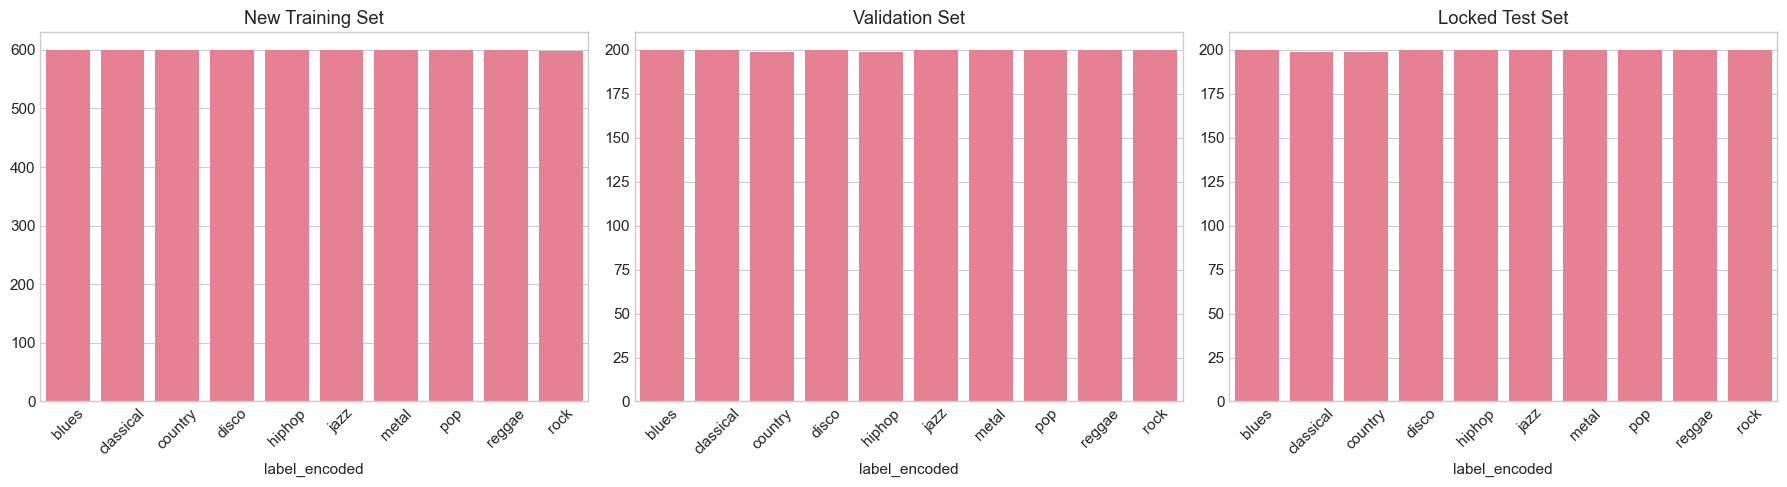

Validation set created only from previous training data. Locked test unchanged.


In [14]:
split_prop = pd.DataFrame({
    "train_pct": (100 * y_train_genres_split.value_counts(normalize=True)).sort_index().round(2),
    "validation_pct": (100 * y_val_genres.value_counts(normalize=True)).sort_index().round(2),
    "locked_test_pct": (100 * y_test_genres_locked.value_counts(normalize=True)).sort_index().round(2),
})
print("Class proportions across train / validation / locked test (%):")
display(split_prop)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title in zip(
    axes,
    [y_train_genres_split, y_val_genres, y_test_genres_locked],
    ["New Training Set", "Validation Set", "Locked Test Set"],
):
    order = CLASS_NAMES
    counts = data.value_counts().reindex(order)
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Validation set created only from previous training data. Locked test unchanged.")


## PART 5 — Rebuild Scaling Without Data Leakage


The pre-saved `X_train_scaled.csv` and `X_test_scaled.csv` from Notebook 1 were scaled **before** a validation split existed. Using them would leak validation information into the scaler.

**Correct approach:** Fit `StandardScaler` on `X_train_tree` only, then transform train, validation, and locked test.


### Cell 8 — Fit Scaler on New Training Set Only


In [15]:
scaler = StandardScaler()
X_train_scaled_arr = scaler.fit_transform(X_train_tree)
X_val_scaled_arr = scaler.transform(X_val_tree)
X_test_scaled_locked_arr = scaler.transform(X_test_tree_locked)

X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=FEATURE_COLUMNS, index=X_train_tree.index)
X_val_scaled = pd.DataFrame(X_val_scaled_arr, columns=FEATURE_COLUMNS, index=X_val_tree.index)
X_test_scaled_locked = pd.DataFrame(
    X_test_scaled_locked_arr, columns=FEATURE_COLUMNS, index=X_test_tree_locked.index
)

print("Scaler refitted on X_train_tree only (after validation split).")
print(f"X_train_scaled shape: {{X_train_scaled.shape}}")
print(f"X_val_scaled shape:   {{X_val_scaled.shape}}")
print(f"X_test_scaled_locked shape: {{X_test_scaled_locked.shape}} (transform only, not used until final eval)")

print(f"\nMean of X_train_scaled (should be ~0): {{X_train_scaled.mean().mean():.6f}}")
print(f"Std of X_train_scaled (should be ~1):  {{X_train_scaled.std().mean():.6f}}")


Scaler refitted on X_train_tree only (after validation split).
X_train_scaled shape: {X_train_scaled.shape}
X_val_scaled shape:   {X_val_scaled.shape}
X_test_scaled_locked shape: {X_test_scaled_locked.shape} (transform only, not used until final eval)

Mean of X_train_scaled (should be ~0): {X_train_scaled.mean().mean():.6f}
Std of X_train_scaled (should be ~1):  {X_train_scaled.std().mean():.6f}


### Cell 9 — Scaling Visualization (Training Data Only)


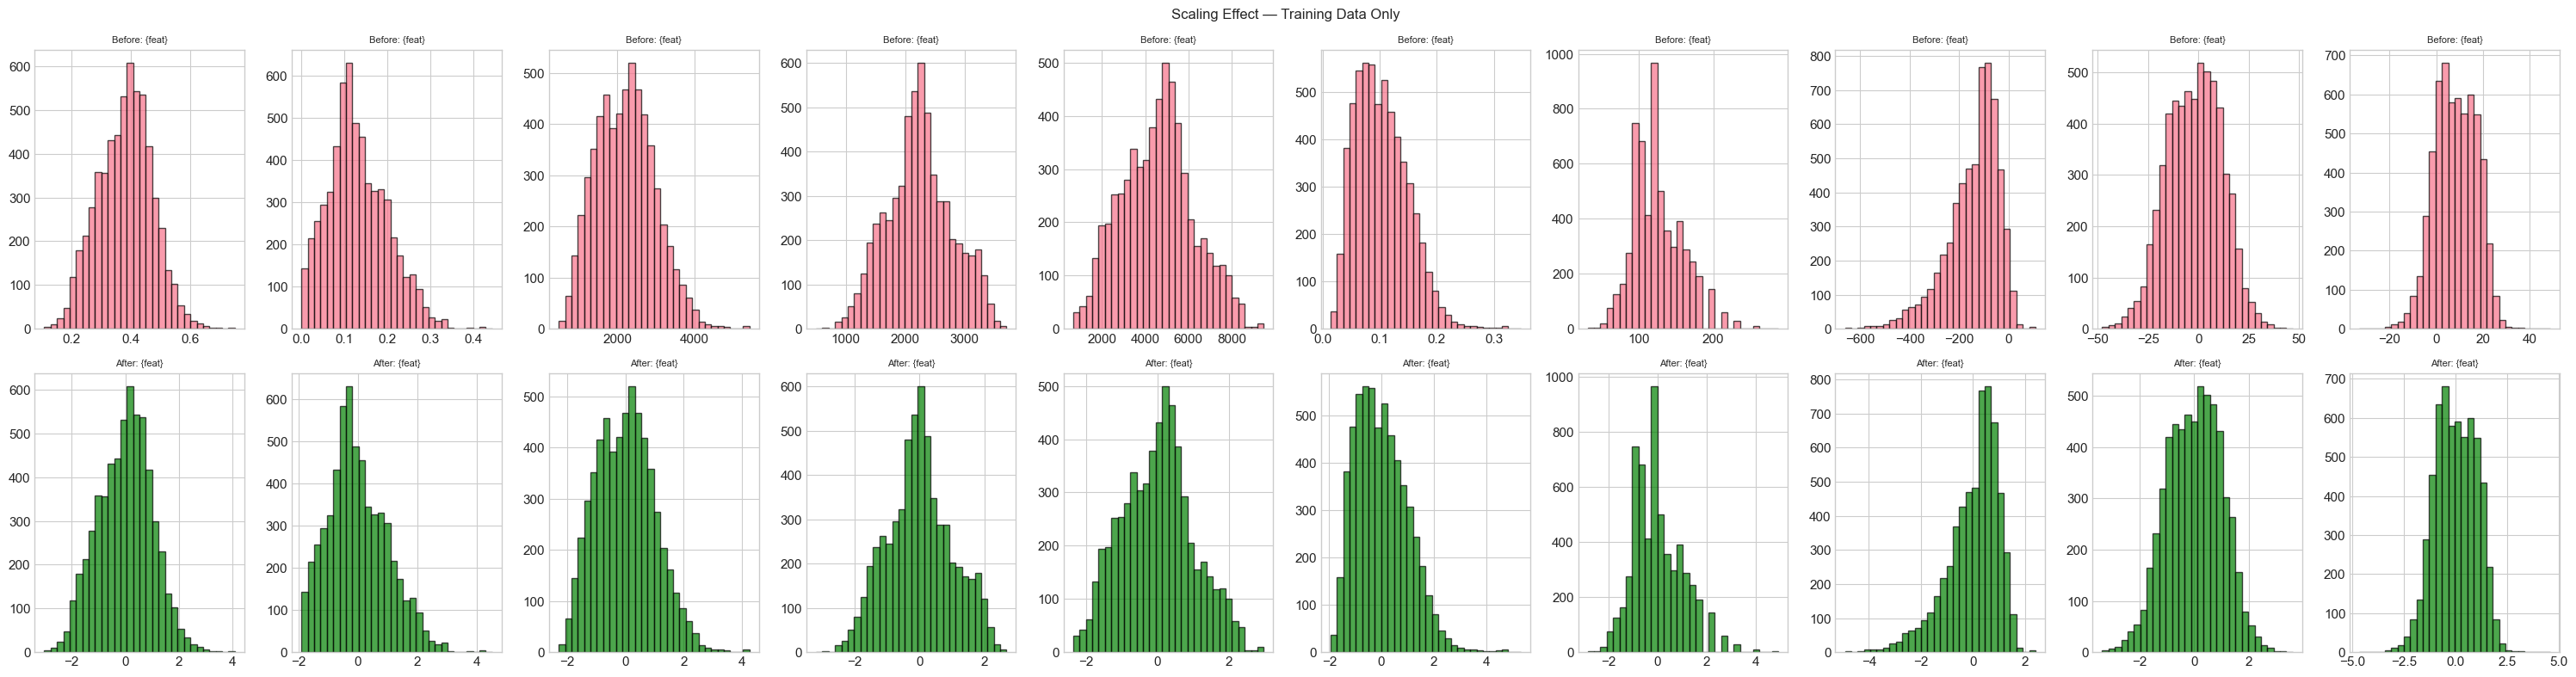

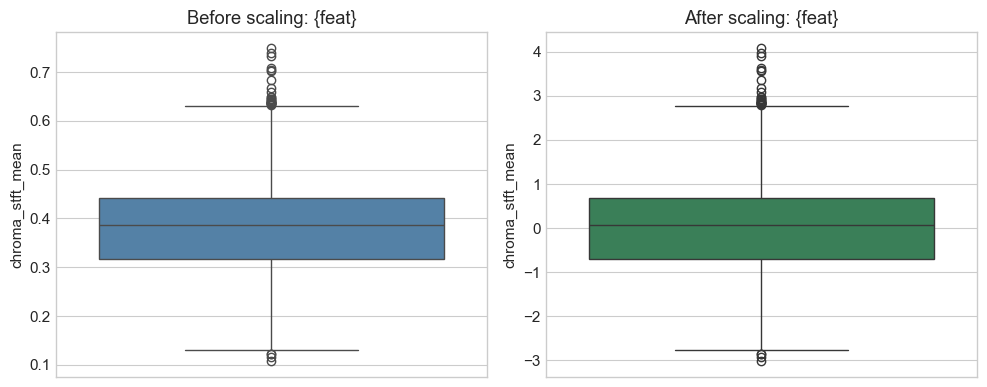

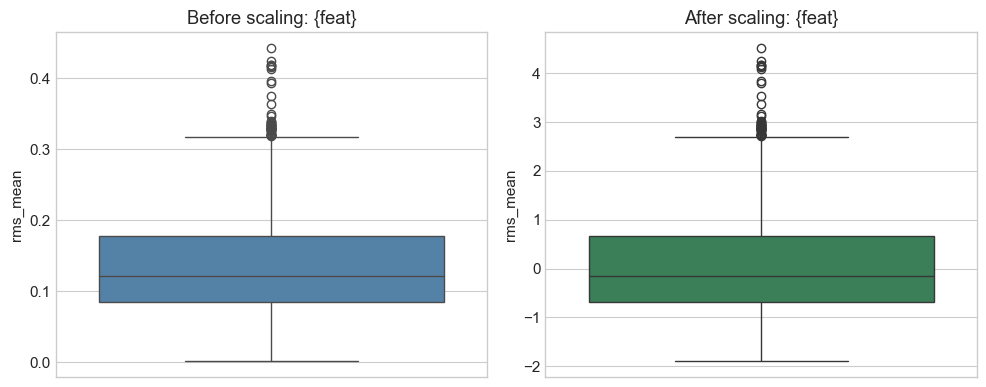

Test feature distributions are NOT visualized (locked test set).


In [16]:
viz_features = [
    "chroma_stft_mean", "rms_mean", "spectral_centroid_mean", "spectral_bandwidth_mean",
    "rolloff_mean", "zero_crossing_rate_mean", "tempo", "mfcc1_mean", "mfcc5_mean", "mfcc10_mean",
]
viz_features = [f for f in viz_features if f in FEATURE_COLUMNS]

fig, axes = plt.subplots(2, len(viz_features), figsize=(3 * len(viz_features), 8))
for i, feat in enumerate(viz_features):
    axes[0, i].hist(X_train_tree[feat], bins=30, edgecolor="black", alpha=0.7)
    axes[0, i].set_title(f"Before: {{feat}}", fontsize=8)
    axes[1, i].hist(X_train_scaled[feat], bins=30, edgecolor="black", alpha=0.7, color="green")
    axes[1, i].set_title(f"After: {{feat}}", fontsize=8)

plt.suptitle("Scaling Effect — Training Data Only", fontsize=12)
plt.tight_layout()
plt.show()

# Boxplots for two features
for feat in viz_features[:2]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.boxplot(y=X_train_tree[feat], ax=axes[0], color="steelblue")
    axes[0].set_title(f"Before scaling: {{feat}}")
    sns.boxplot(y=X_train_scaled[feat], ax=axes[1], color="seagreen")
    axes[1].set_title(f"After scaling: {{feat}}")
    plt.tight_layout()
    plt.show()

print("Test feature distributions are NOT visualized (locked test set).")


## PART 6 — Define Evaluation Utilities


### Cell 10 — Reusable Evaluation Functions


In [17]:
def evaluate_model(model, X, y, class_names, dataset_name="Validation"):
    """Evaluate a fitted model and return metrics and predictions."""
    y_pred = model.predict(X)
    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y, y_pred),
        "macro_precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y, y_pred, average="weighted", zero_division=0),
    }
    report = pd.DataFrame(
        classification_report(y, y_pred, target_names=class_names, zero_division=0, output_dict=True)
    ).transpose()
    return metrics, report, y_pred


def plot_confusion_matrix(y_true, y_pred, class_names, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt, vmin = ".2f", 0
    else:
        fmt, vmin = "d", None
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, ax=ax, vmin=vmin)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_metric_bar_chart(results_df, metric_column, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=results_df, x="model_name", y=metric_column, ax=ax)
    ax.set_title(title)
    ax.set_ylabel(metric_column)
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


def get_per_class_f1(y_true, y_pred, class_names, model_name):
    f1s = f1_score(y_true, y_pred, average=None, zero_division=0, labels=list(range(len(class_names))))
    return pd.DataFrame({
        "model_name": model_name,
        "genre": class_names,
        "f1_score": f1s,
    })


def train_and_time_model(model, X_train, y_train):
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    return model, elapsed

print("Evaluation utilities defined.")


Evaluation utilities defined.


## PART 7 — Baseline Model Training


### Cell 11 — Baseline Logistic Regression


Baseline Logistic Regression — training time: {time_linear:.2f} s
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}


,precision,recall,f1-score,support
blues,0.7136,0.7350,0.7241,200.0000
classical,0.9340,0.9200,0.9270,200.0000
country,0.6037,0.6583,0.6298,199.0000
disco,0.6283,0.6000,0.6138,200.0000
hiphop,0.7222,0.6533,0.6860,199.0000
jazz,0.7511,0.8750,0.8083,200.0000
metal,0.7560,0.7900,0.7726,200.0000
pop,0.7919,0.7800,0.7859,200.0000
reggae,0.6716,0.6750,0.6733,200.0000
rock,0.5689,0.4750,0.5177,200.0000


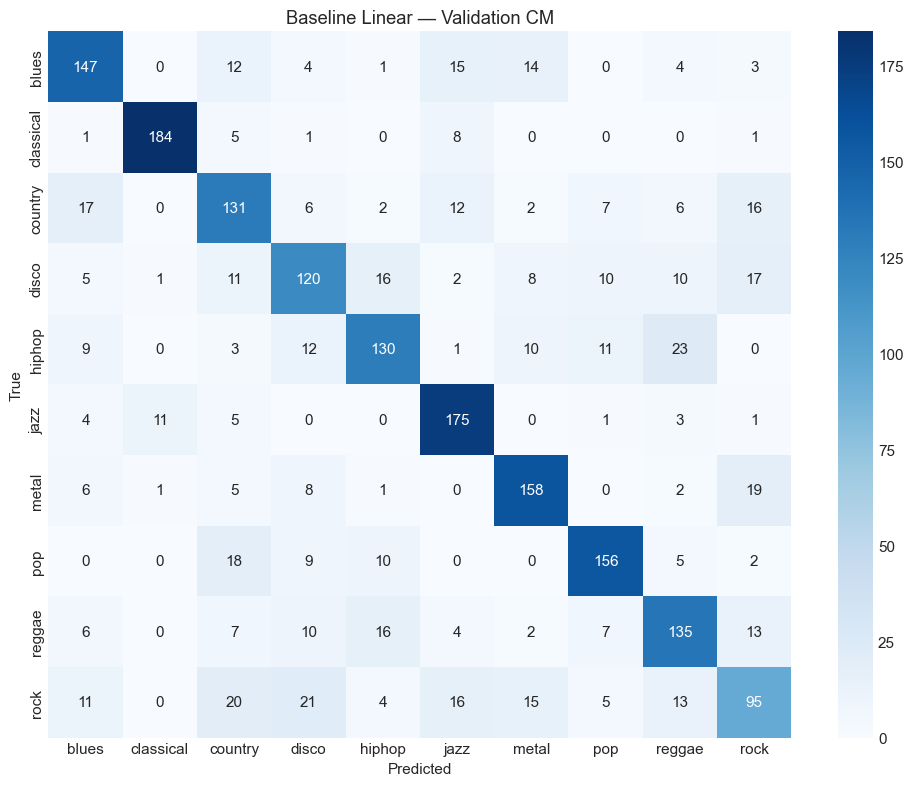

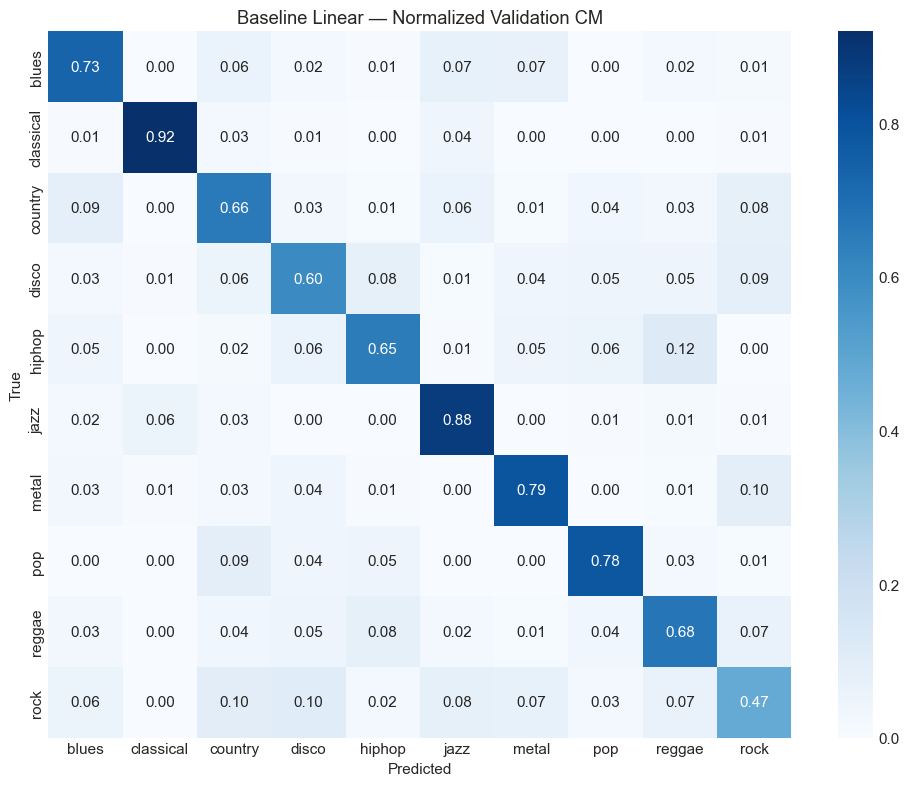

In [18]:
baseline_linear = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    multi_class="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

baseline_linear, time_linear = train_and_time_model(baseline_linear, X_train_scaled, y_train)
metrics_linear, report_linear, pred_linear = evaluate_model(
    baseline_linear, X_val_scaled, y_val, CLASS_NAMES, "Validation"
)
print(f"Baseline Logistic Regression — training time: {{time_linear:.2f}} s")
for k, v in metrics_linear.items():
    if k != "dataset":
        print(f"  {{k}}: {{v:.4f}}")
display(report_linear.round(4))
plot_confusion_matrix(y_val, pred_linear, CLASS_NAMES, "Baseline Linear — Validation CM")
plot_confusion_matrix(y_val, pred_linear, CLASS_NAMES, "Baseline Linear — Normalized Validation CM", normalize=True)


### Cell 12 — Baseline Random Forest


Baseline Random Forest — training time: {time_rf:.2f} s
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}


,precision,recall,f1-score,support
blues,0.8974,0.8750,0.8861,200.0000
classical,0.9216,0.9400,0.9307,200.0000
country,0.7870,0.8543,0.8193,199.0000
disco,0.8290,0.8000,0.8142,200.0000
hiphop,0.8659,0.7789,0.8201,199.0000
jazz,0.8430,0.9400,0.8889,200.0000
metal,0.8598,0.9200,0.8889,200.0000
pop,0.8980,0.8800,0.8889,200.0000
reggae,0.8203,0.8900,0.8537,200.0000
rock,0.8509,0.6850,0.7590,200.0000


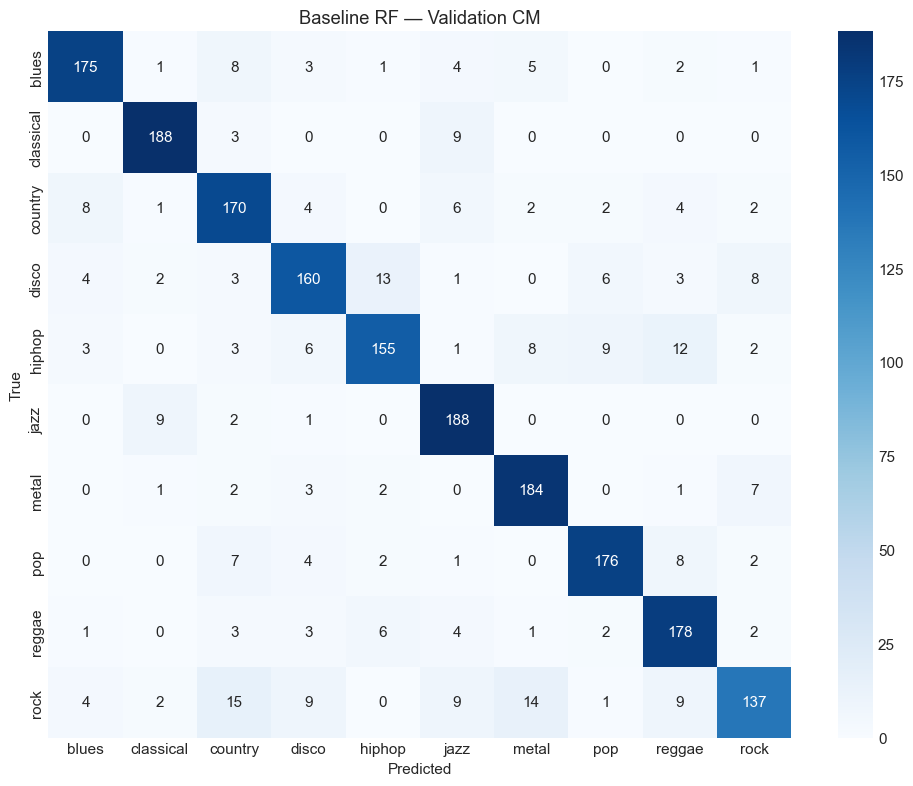

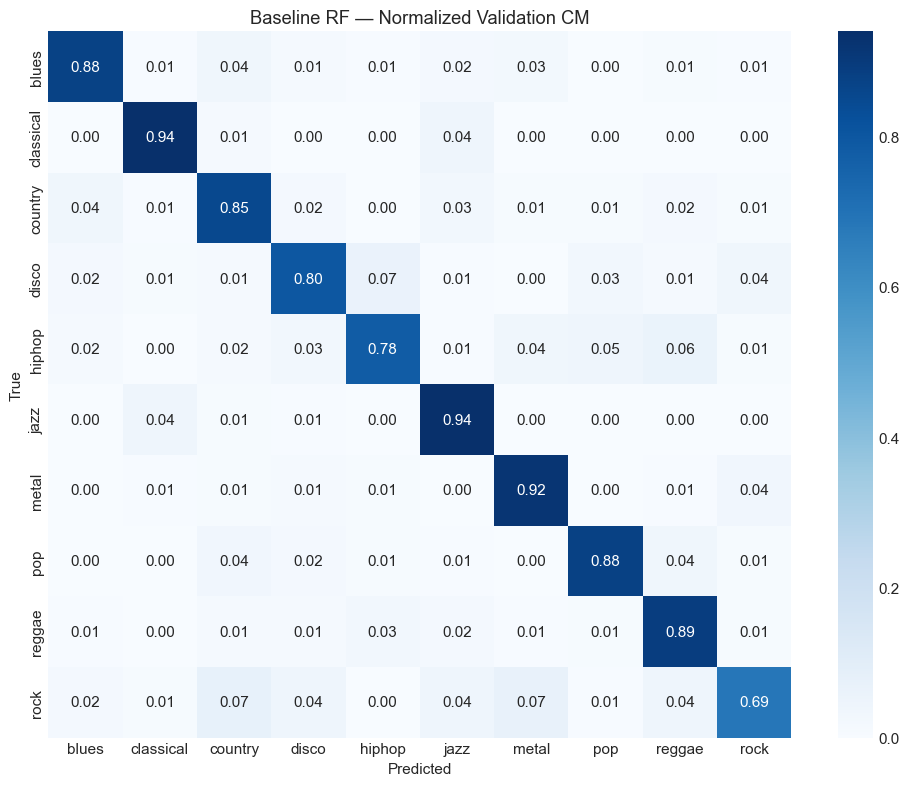

In [19]:
baseline_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight=None,
)

baseline_rf, time_rf = train_and_time_model(baseline_rf, X_train_tree, y_train)
metrics_rf, report_rf, pred_rf = evaluate_model(
    baseline_rf, X_val_tree, y_val, CLASS_NAMES, "Validation"
)
print(f"Baseline Random Forest — training time: {{time_rf:.2f}} s")
for k, v in metrics_rf.items():
    if k != "dataset":
        print(f"  {{k}}: {{v:.4f}}")
display(report_rf.round(4))
plot_confusion_matrix(y_val, pred_rf, CLASS_NAMES, "Baseline RF — Validation CM")
plot_confusion_matrix(y_val, pred_rf, CLASS_NAMES, "Baseline RF — Normalized Validation CM", normalize=True)


### Cell 13 — Baseline Neural Network


Baseline MLP — training time: {time_mlp:.2f} s
  Iterations: {baseline_mlp.n_iter_}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}
  {k}: {v:.4f}


,precision,recall,f1-score,support
blues,0.8537,0.8750,0.8642,200.0000
classical,0.9337,0.9150,0.9242,200.0000
country,0.7961,0.8241,0.8099,199.0000
disco,0.8081,0.8000,0.8040,200.0000
hiphop,0.8677,0.8241,0.8454,199.0000
jazz,0.8443,0.8950,0.8689,200.0000
metal,0.8713,0.8800,0.8756,200.0000
pop,0.8934,0.8800,0.8866,200.0000
reggae,0.8098,0.8300,0.8198,200.0000
rock,0.7766,0.7300,0.7526,200.0000


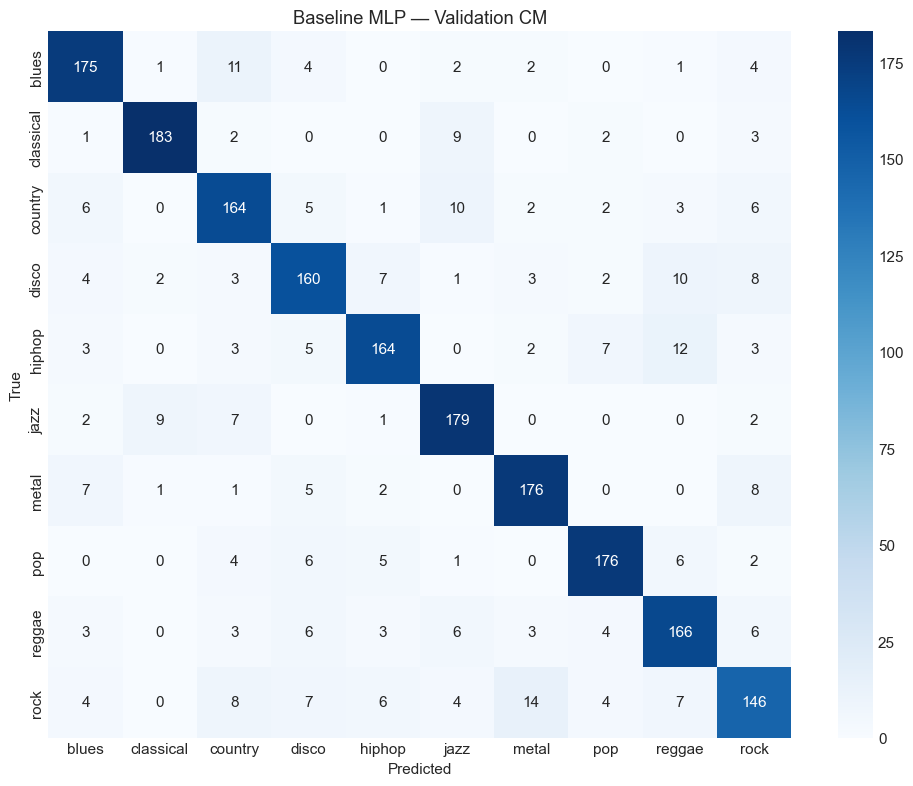

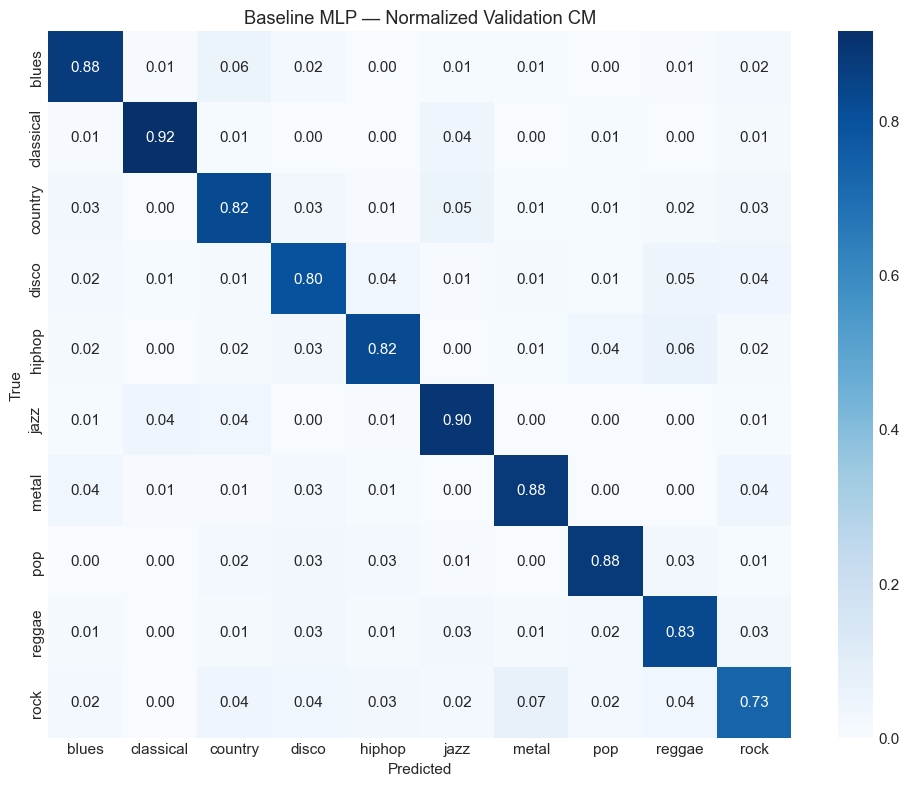

In [20]:
baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)

baseline_mlp, time_mlp = train_and_time_model(baseline_mlp, X_train_scaled, y_train)
metrics_mlp, report_mlp, pred_mlp = evaluate_model(
    baseline_mlp, X_val_scaled, y_val, CLASS_NAMES, "Validation"
)
print(f"Baseline MLP — training time: {{time_mlp:.2f}} s")
print(f"  Iterations: {{baseline_mlp.n_iter_}}")
for k, v in metrics_mlp.items():
    if k != "dataset":
        print(f"  {{k}}: {{v:.4f}}")
display(report_mlp.round(4))
plot_confusion_matrix(y_val, pred_mlp, CLASS_NAMES, "Baseline MLP — Validation CM")
plot_confusion_matrix(y_val, pred_mlp, CLASS_NAMES, "Baseline MLP — Normalized Validation CM", normalize=True)

baseline_preds = {
    "Logistic Regression": pred_linear,
    "Random Forest": pred_rf,
    "Neural Network": pred_mlp,
}


## PART 8 — Baseline Model Comparison on Validation Set


### Cell 14 — Baseline Comparison Table and Plots


Baseline validation comparison:


,model_name,training_time_seconds,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_precision,validation_weighted_recall,validation_weighted_f1
0,Logistic Regression,14.3588,0.7162,0.7141,0.7162,0.7139,0.7142,0.7162,0.7139
1,Random Forest,18.5337,0.8564,0.8573,0.8563,0.8550,0.8573,0.8564,0.8550
2,Neural Network,20.5948,0.8453,0.8455,0.8453,0.8451,0.8455,0.8453,0.8451


Columns in baseline_results:
['model_name', 'training_time_seconds', 'validation_accuracy', 'validation_macro_precision', 'validation_macro_recall', 'validation_macro_f1', 'validation_weighted_precision', 'validation_weighted_recall', 'validation_weighted_f1']


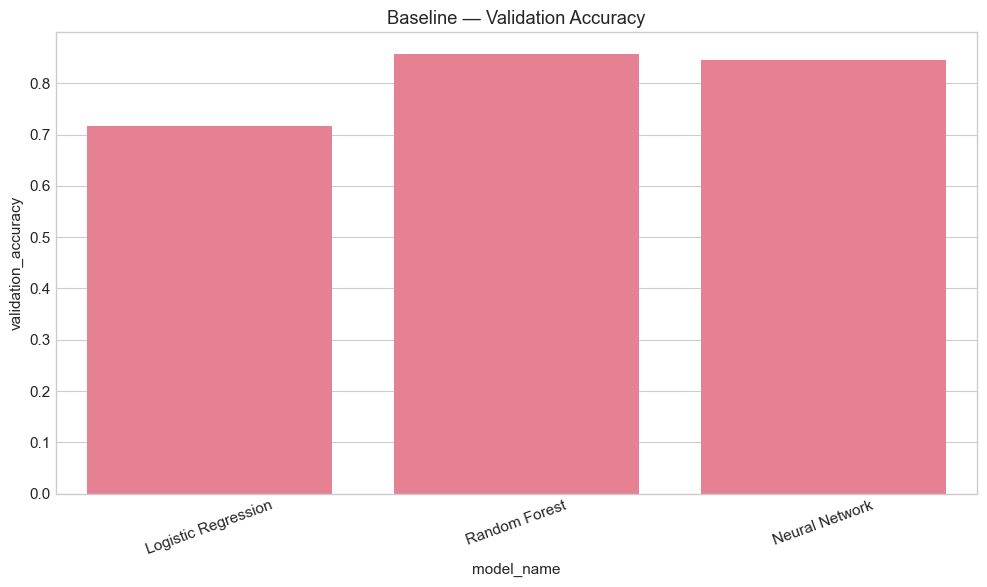

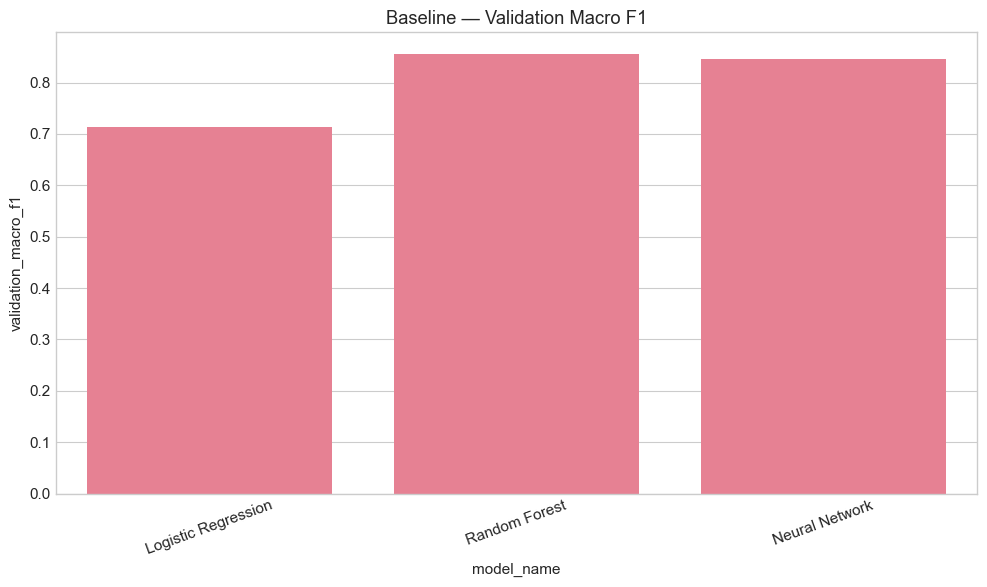

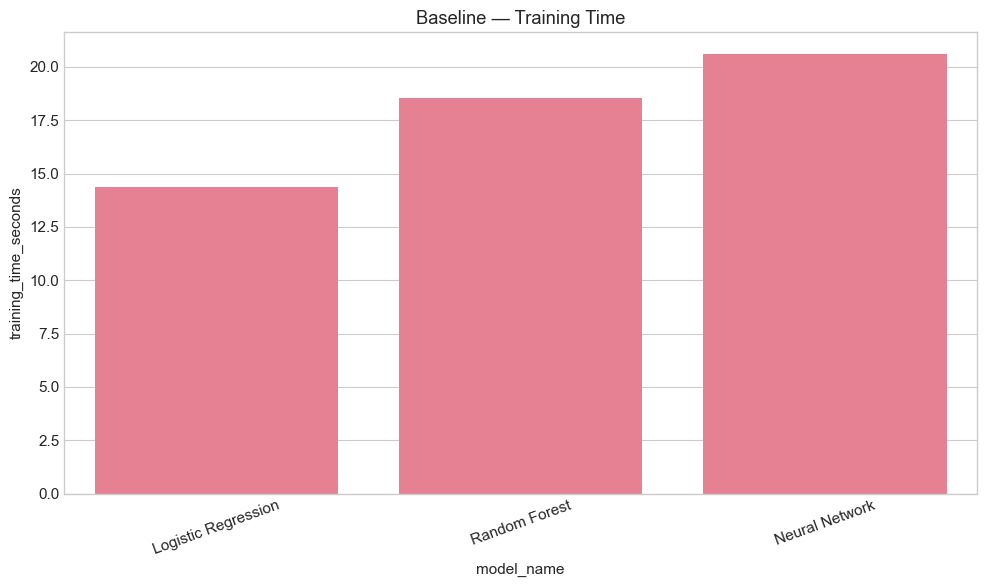

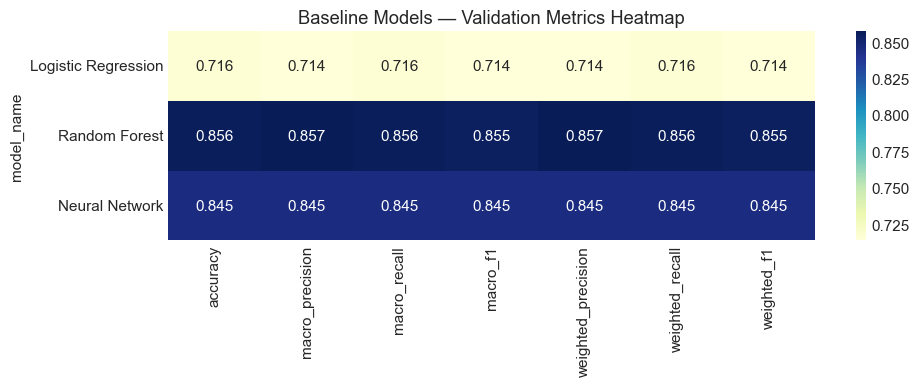


Best baseline by validation macro F1: Random Forest
Interpretation: Compare accuracy, macro F1, and training time across linear, ensemble, and neural approaches.
Random Forest is often strong on tabular audio features; Logistic Regression is fastest and most interpretable.


In [22]:
baseline_results = pd.DataFrame([
    {
        "model_name": "Logistic Regression",
        "training_time_seconds": time_linear,
        **{f"validation_{k}": v for k, v in metrics_linear.items() if k != "dataset"},
    },
    {
        "model_name": "Random Forest",
        "training_time_seconds": time_rf,
        **{f"validation_{k}": v for k, v in metrics_rf.items() if k != "dataset"},
    },
    {
        "model_name": "Neural Network",
        "training_time_seconds": time_mlp,
        **{f"validation_{k}": v for k, v in metrics_mlp.items() if k != "dataset"},
    },
])

print("Baseline validation comparison:")
display(baseline_results.round(4))

print("Columns in baseline_results:")
print(baseline_results.columns.tolist())

plot_metric_bar_chart(baseline_results, "validation_accuracy", "Baseline — Validation Accuracy")
plot_metric_bar_chart(baseline_results, "validation_macro_f1", "Baseline — Validation Macro F1")
plot_metric_bar_chart(baseline_results, "training_time_seconds", "Baseline — Training Time")

# Metrics heatmap
heat_cols = [c for c in baseline_results.columns if c.startswith("validation_")]
heat_df = baseline_results.set_index("model_name")[heat_cols]
heat_df.columns = [c.replace("validation_", "") for c in heat_df.columns]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Baseline Models — Validation Metrics Heatmap")
plt.tight_layout()
plt.show()

best_baseline = baseline_results.loc[
    baseline_results["validation_macro_f1"].idxmax(),
    "model_name"
]

print(f"\nBest baseline by validation macro F1: {best_baseline}")
print("Interpretation: Compare accuracy, macro F1, and training time across linear, ensemble, and neural approaches.")
print("Random Forest is often strong on tabular audio features; Logistic Regression is fastest and most interpretable.")

### Academic interpretation (baseline)

- **Best validation macro F1** indicates the strongest equal-weighted multiclass performance at this stage.
- **Training time** highlights computational trade-offs (RF and MLP typically slower than logistic regression).
- **Interpretability:** Logistic Regression coefficients are directly readable; Random Forest provides feature importances; MLP has limited transparency.
- Differences across models reflect how well each hypothesis class matches the audio feature space.


## PART 9 — Validation Error Analysis for Baseline Models


### Cell 15 — Error Analysis Functions and Loop



=== {model_name} — Validation Error Analysis ===
Total errors: {n_errors} / {len(df_err)} ({error_rate:.2f}% error rate)

Top 10 confusion pairs (true -> pred):


,true_label,pred_label,count
35,hiphop,reggae,23
64,rock,disco,21
63,rock,country,20
48,metal,rock,19
49,pop,country,18
12,country,blues,17
28,disco,rock,17
66,rock,jazz,16
23,disco,hiphop,16
19,country,rock,16


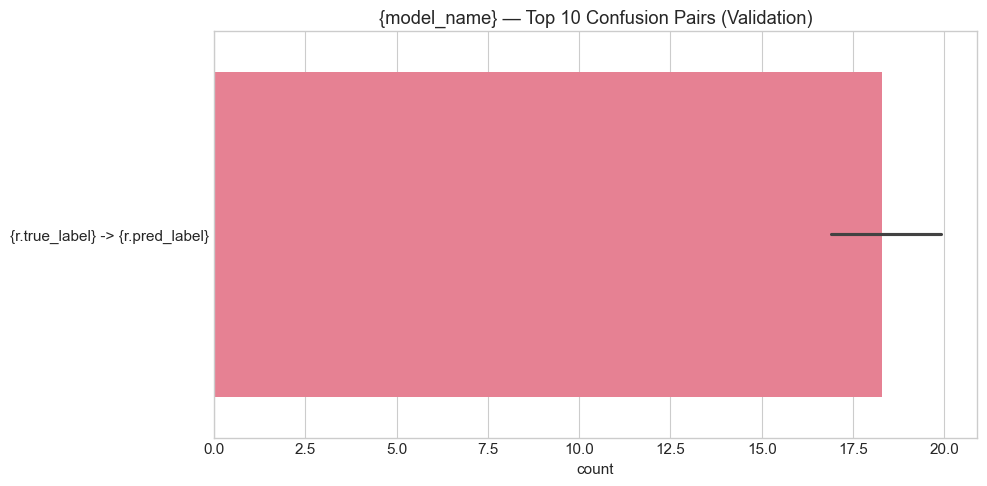


Per-class F1:


,model_name,genre,f1_score
0,Logistic Regression,blues,0.7241
1,Logistic Regression,classical,0.9270
2,Logistic Regression,country,0.6298
3,Logistic Regression,disco,0.6138
4,Logistic Regression,hiphop,0.6860
5,Logistic Regression,jazz,0.8083
6,Logistic Regression,metal,0.7726
7,Logistic Regression,pop,0.7859
8,Logistic Regression,reggae,0.6733
9,Logistic Regression,rock,0.5177


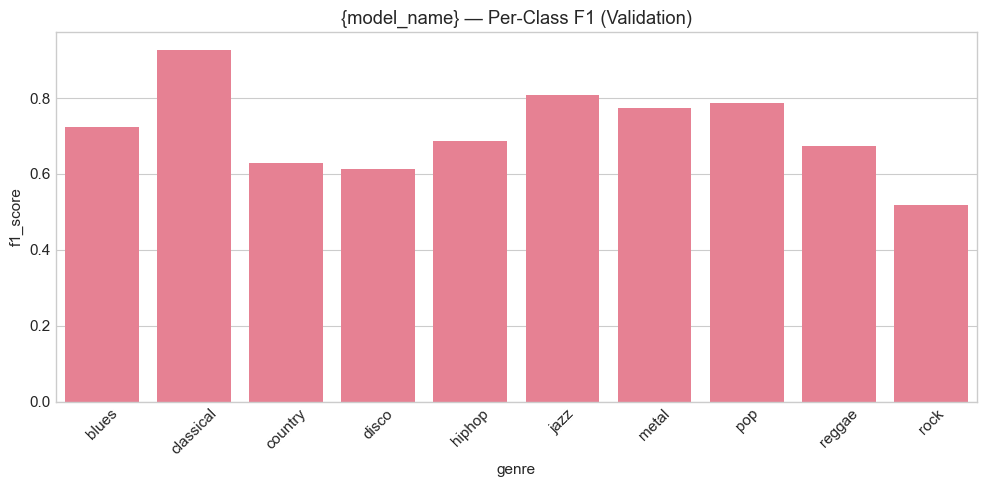

Easiest genre (highest F1): {easiest}
Hardest genre (lowest F1): {hardest}
Most confused pair: {top_pair['true_label']} -> {top_pair['pred_label']} ({top_pair['count']} cases)

=== {model_name} — Validation Error Analysis ===
Total errors: {n_errors} / {len(df_err)} ({error_rate:.2f}% error rate)

Top 10 confusion pairs (true -> pred):


,true_label,pred_label,count
59,rock,country,15
62,rock,metal,14
21,disco,hiphop,13
32,hiphop,reggae,12
64,rock,reggae,9
60,rock,disco,9
34,jazz,classical,9
9,classical,jazz,9
31,hiphop,pop,9
61,rock,jazz,9


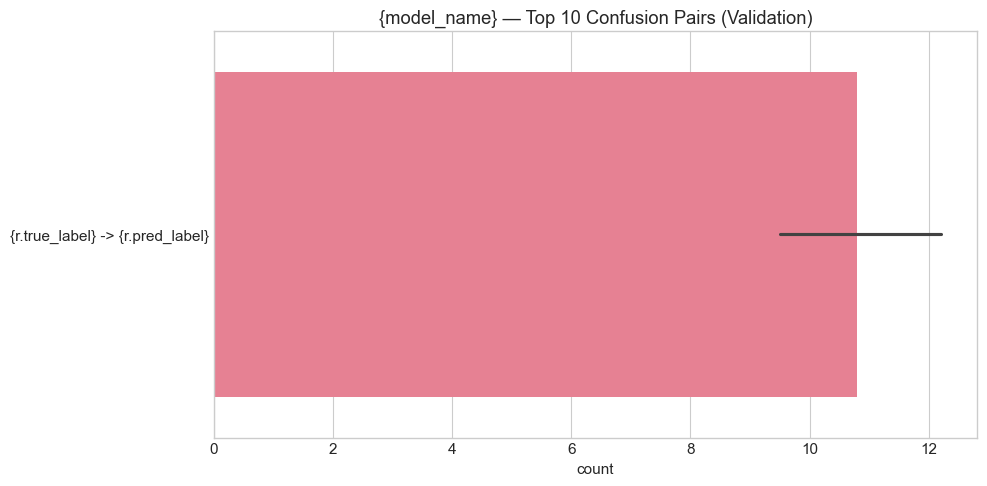


Per-class F1:


,model_name,genre,f1_score
0,Random Forest,blues,0.8861
1,Random Forest,classical,0.9307
2,Random Forest,country,0.8193
3,Random Forest,disco,0.8142
4,Random Forest,hiphop,0.8201
5,Random Forest,jazz,0.8889
6,Random Forest,metal,0.8889
7,Random Forest,pop,0.8889
8,Random Forest,reggae,0.8537
9,Random Forest,rock,0.7590


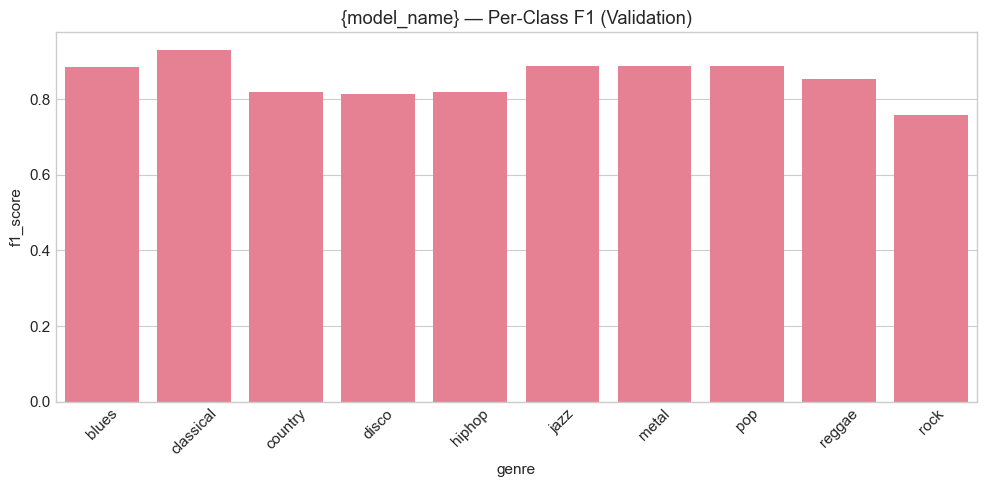

Easiest genre (highest F1): {easiest}
Hardest genre (lowest F1): {hardest}
Most confused pair: {top_pair['true_label']} -> {top_pair['pred_label']} ({top_pair['count']} cases)

=== {model_name} — Validation Error Analysis ===
Total errors: {n_errors} / {len(df_err)} ({error_rate:.2f}% error rate)

Top 10 confusion pairs (true -> pred):


,true_label,pred_label,count
66,rock,metal,14
34,hiphop,reggae,12
1,blues,country,11
15,country,jazz,10
27,disco,reggae,10
37,jazz,classical,9
9,classical,jazz,9
28,disco,rock,8
62,rock,country,8
46,metal,rock,8


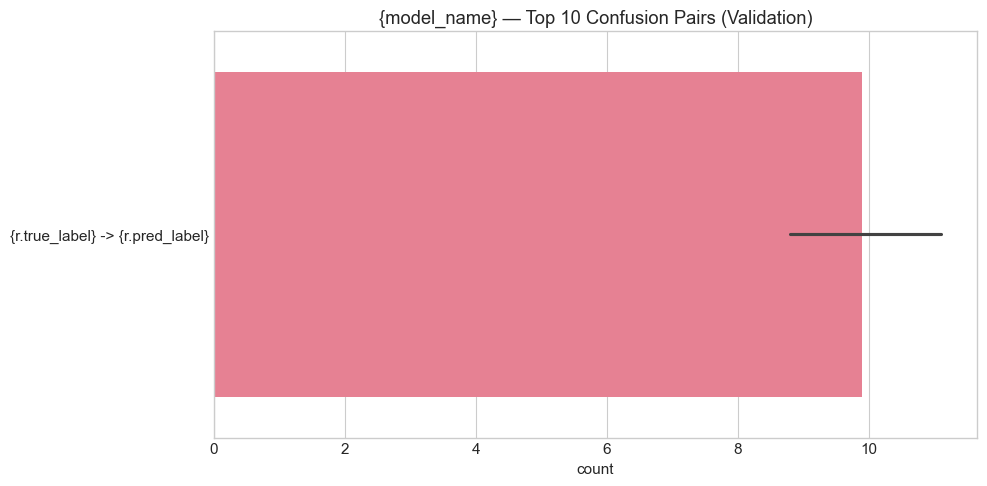


Per-class F1:


,model_name,genre,f1_score
0,Neural Network,blues,0.8642
1,Neural Network,classical,0.9242
2,Neural Network,country,0.8099
3,Neural Network,disco,0.8040
4,Neural Network,hiphop,0.8454
5,Neural Network,jazz,0.8689
6,Neural Network,metal,0.8756
7,Neural Network,pop,0.8866
8,Neural Network,reggae,0.8198
9,Neural Network,rock,0.7526


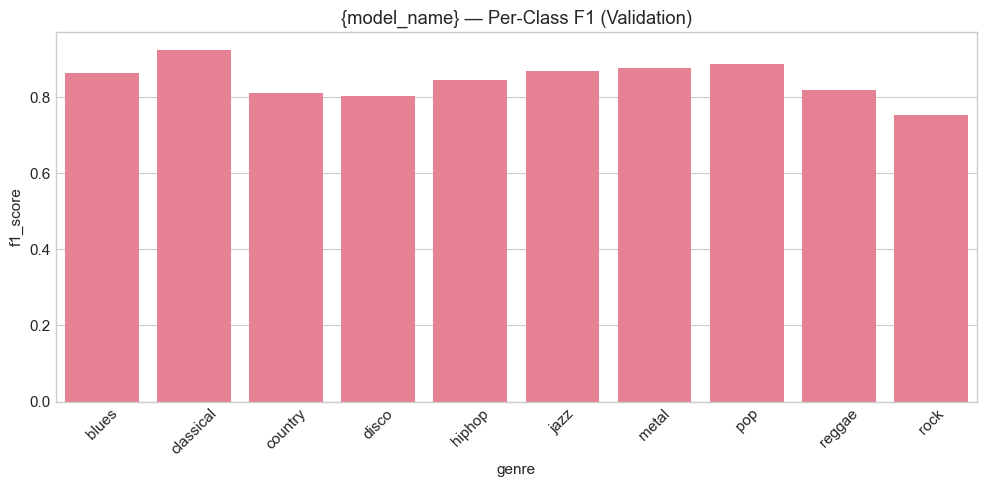

Easiest genre (highest F1): {easiest}
Hardest genre (lowest F1): {hardest}
Most confused pair: {top_pair['true_label']} -> {top_pair['pred_label']} ({top_pair['count']} cases)


In [23]:
def validation_error_analysis(y_true, y_pred, model_name, class_names):
    df_err = pd.DataFrame({
        "true_encoded": y_true.values,
        "pred_encoded": y_pred,
        "true_label": [class_names[i] for i in y_true.values],
        "pred_label": [class_names[i] for i in y_pred],
    })
    df_err["correct"] = df_err["true_encoded"] == df_err["pred_encoded"]

    n_errors = (~df_err["correct"]).sum()
    error_rate = 100 * n_errors / len(df_err)

    wrong = df_err[~df_err["correct"]]
    confusion_pairs = (
        wrong.groupby(["true_label", "pred_label"]).size().reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print(f"\n=== {{model_name}} — Validation Error Analysis ===")
    print(f"Total errors: {{n_errors}} / {{len(df_err)}} ({{error_rate:.2f}}% error rate)")

    print("\nTop 10 confusion pairs (true -> pred):")
    display(confusion_pairs.head(10))

    if len(confusion_pairs) > 0:
        top_pairs = confusion_pairs.head(10)
        fig, ax = plt.subplots(figsize=(10, 5))
        labels = [f"{{r.true_label}} -> {{r.pred_label}}" for r in top_pairs.itertuples()]
        sns.barplot(x="count", y=labels, data=top_pairs, orient="h", ax=ax)
        ax.set_title(f"{{model_name}} — Top 10 Confusion Pairs (Validation)")
        plt.tight_layout()
        plt.show()

    per_class = get_per_class_f1(y_true, y_pred, class_names, model_name)
    print("\nPer-class F1:")
    display(per_class.round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=per_class, x="genre", y="f1_score", ax=ax)
    ax.set_title(f"{{model_name}} — Per-Class F1 (Validation)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    easiest = per_class.loc[per_class["f1_score"].idxmax(), "genre"]
    hardest = per_class.loc[per_class["f1_score"].idxmin(), "genre"]
    print(f"Easiest genre (highest F1): {{easiest}}")
    print(f"Hardest genre (lowest F1): {{hardest}}")
    if len(confusion_pairs) > 0:
        top_pair = confusion_pairs.iloc[0]
        print(f"Most confused pair: {{top_pair['true_label']}} -> {{top_pair['pred_label']}} ({{top_pair['count']}} cases)")

    return df_err, per_class, confusion_pairs

baseline_error_results = {}
baseline_per_class_list = []
for name, preds in baseline_preds.items():
    df_e, pc, cp = validation_error_analysis(y_val, preds, name, CLASS_NAMES)
    baseline_error_results[name] = (df_e, cp)
    baseline_per_class_list.append(pc)

validation_per_class_f1_baseline = pd.concat(baseline_per_class_list, ignore_index=True)


## PART 10 — Memory-Efficient Hyperparameter Tuning Strategy


### Tuning principles (memory-efficient, laptop-friendly)

| Rule | Rationale |
|------|-----------|
| Small parameter grids | Avoid exhaustive search explosion |
| `cv=3` | Balance stability vs. compute |
| `scoring="f1_macro"` | Equal weight per genre in multiclass setting |
| `RandomizedSearchCV` for RF | Explore space without evaluating every combination |
| Small `GridSearchCV` for logistic | Few C values, fixed solver |
| Manual loop for MLP | Train one network at a time; release memory with `del` |
| `n_jobs=-1` for LR and RF only | Parallelize tree/linear search |
| `n_jobs=1` for MLP / permutation | Avoid memory spikes |
| **Validation macro F1** for final selection | Aligns with macro-averaged multiclass goals |
| **No locked test** until Part 16 | Unbiased final estimate |

**Why macro F1?** In multiclass genre classification, macro F1 averages per-class F1 scores, treating all genres equally—important when classes are roughly balanced but errors on minority-like genres still matter.

**Selection criterion:** Best validation macro F1 after tuning; locked test evaluated **once** for the single winner.


## PART 11 — Hyperparameter Tuning for Linear Classifier


### Cell 16 — GridSearchCV for Logistic Regression


Tuning Logistic Regression...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best parameters: {grid_linear.best_params_}
Best CV macro F1: {grid_linear.best_score_:.4f}
Tuning time: {time_tune_linear:.2f} s


,precision,recall,f1-score,support
blues,0.7350,0.7350,0.7350,200.0000
classical,0.9289,0.9150,0.9219,200.0000
country,0.6083,0.6633,0.6346,199.0000
disco,0.6237,0.6050,0.6142,200.0000
hiphop,0.7238,0.6583,0.6895,199.0000
jazz,0.7478,0.8600,0.8000,200.0000
metal,0.7465,0.7950,0.7700,200.0000
pop,0.7929,0.7850,0.7889,200.0000
reggae,0.6784,0.6750,0.6767,200.0000
rock,0.5562,0.4700,0.5095,200.0000


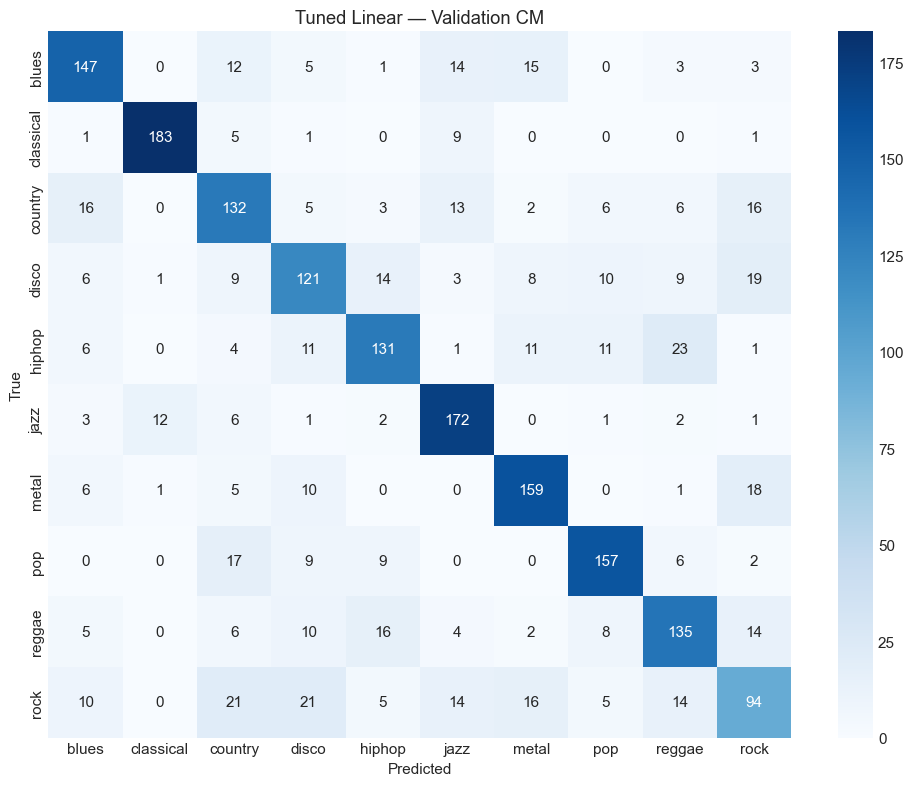

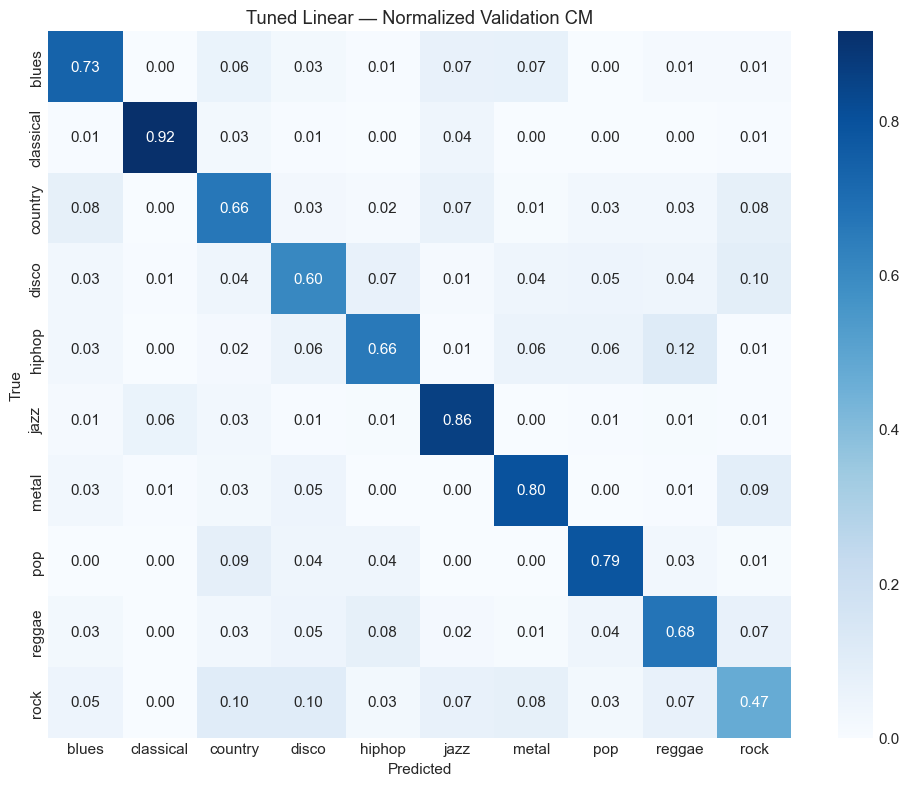

In [24]:
param_grid_linear = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [1000],
}

grid_linear = GridSearchCV(
    estimator=LogisticRegression(multi_class="auto", random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid_linear,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

print("Tuning Logistic Regression...")
start = time.time()
grid_linear.fit(X_train_scaled, y_train)
time_tune_linear = time.time() - start

best_linear = grid_linear.best_estimator_
print(f"\nBest parameters: {{grid_linear.best_params_}}")
print(f"Best CV macro F1: {{grid_linear.best_score_:.4f}}")
print(f"Tuning time: {{time_tune_linear:.2f}} s")

metrics_tune_linear, report_tune_linear, pred_tune_linear = evaluate_model(
    best_linear, X_val_scaled, y_val, CLASS_NAMES, "Validation"
)
display(report_tune_linear.round(4))
plot_confusion_matrix(y_val, pred_tune_linear, CLASS_NAMES, "Tuned Linear — Validation CM")
plot_confusion_matrix(y_val, pred_tune_linear, CLASS_NAMES, "Tuned Linear — Normalized Validation CM", normalize=True)


## PART 12 — Hyperparameter Tuning for Random Forest


### Cell 17 — RandomizedSearchCV for Random Forest


Tuning Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {rand_rf.best_params_}
Best CV macro F1: {rand_rf.best_score_:.4f}
Tuning time: {time_tune_rf:.2f} s


,precision,recall,f1-score,support
blues,0.8750,0.8750,0.8750,200.0000
classical,0.9135,0.9500,0.9314,200.0000
country,0.7664,0.8241,0.7942,199.0000
disco,0.8010,0.7850,0.7929,200.0000
hiphop,0.8830,0.7588,0.8162,199.0000
jazz,0.8525,0.9250,0.8873,200.0000
metal,0.8692,0.9300,0.8986,200.0000
pop,0.8969,0.8700,0.8832,200.0000
reggae,0.7956,0.8950,0.8424,200.0000
rock,0.8616,0.6850,0.7632,200.0000


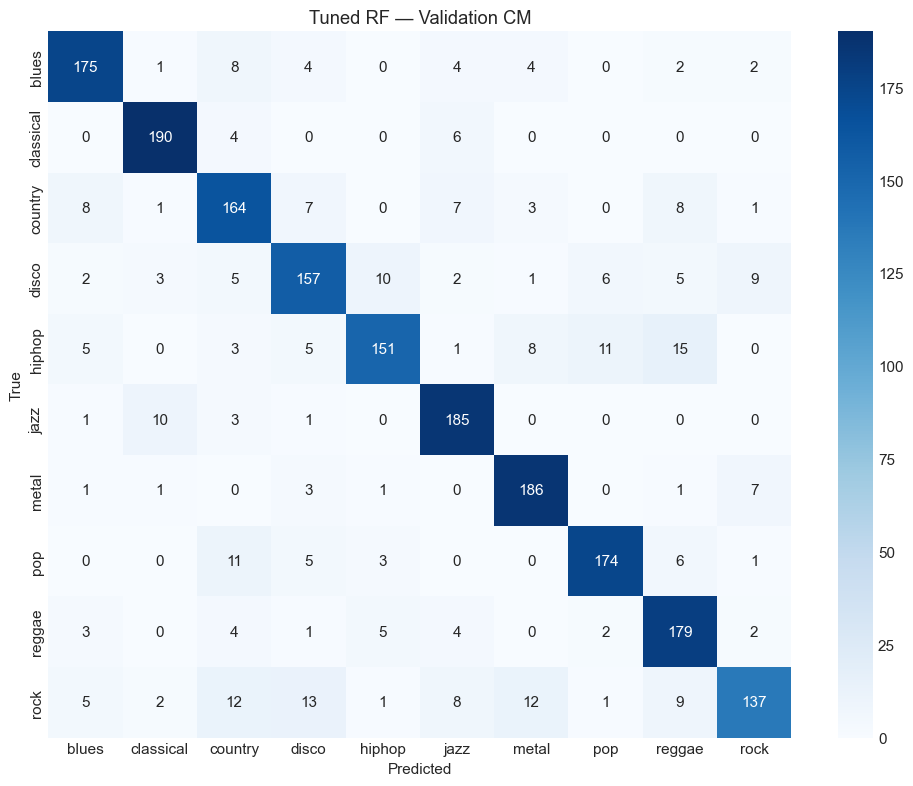

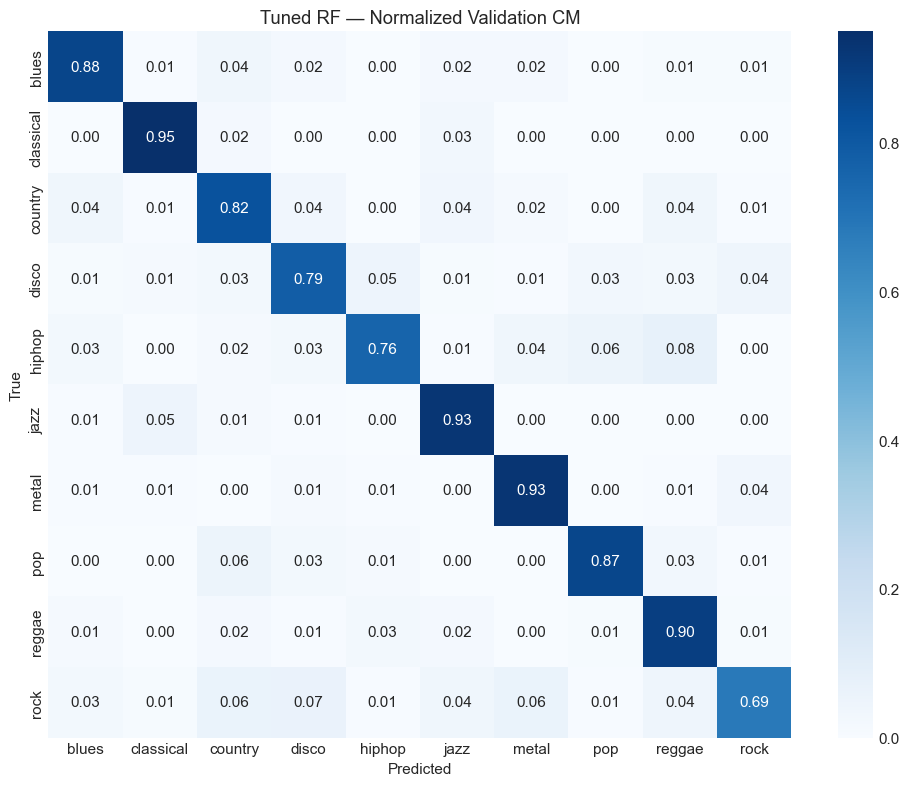

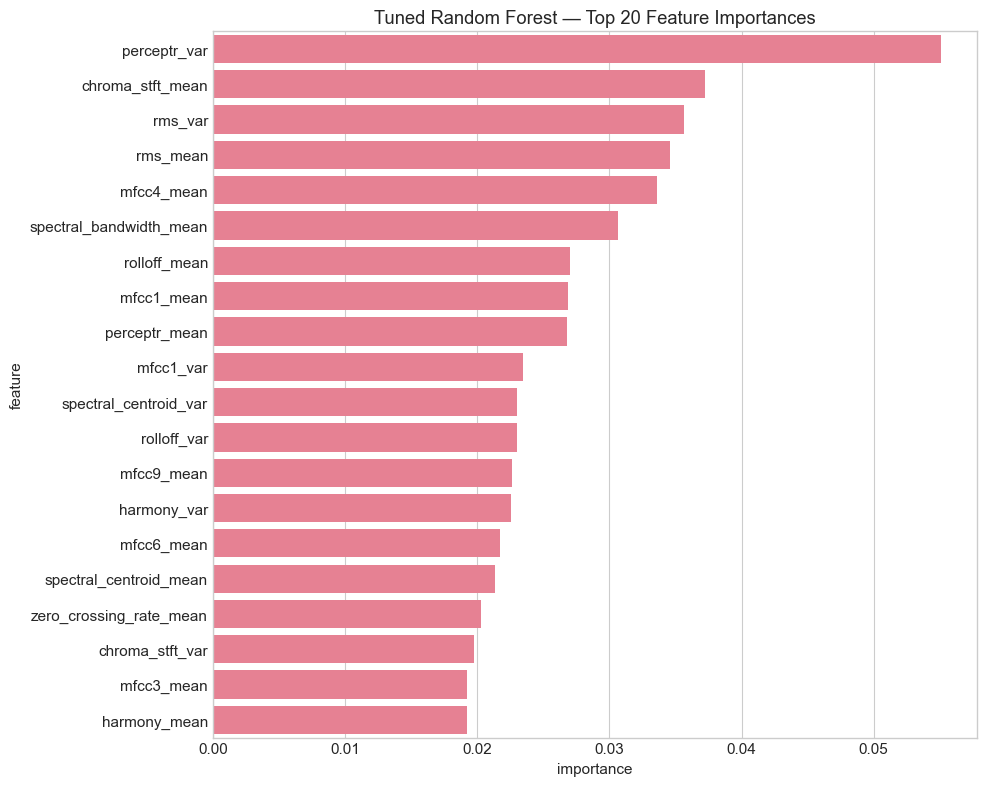

In [25]:
param_dist_rf = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

rand_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=12,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

print("Tuning Random Forest...")
start = time.time()
rand_rf.fit(X_train_tree, y_train)
time_tune_rf = time.time() - start

best_rf = rand_rf.best_estimator_
print(f"\nBest parameters: {{rand_rf.best_params_}}")
print(f"Best CV macro F1: {{rand_rf.best_score_:.4f}}")
print(f"Tuning time: {{time_tune_rf:.2f}} s")

metrics_tune_rf, report_tune_rf, pred_tune_rf = evaluate_model(
    best_rf, X_val_tree, y_val, CLASS_NAMES, "Validation"
)
display(report_tune_rf.round(4))
plot_confusion_matrix(y_val, pred_tune_rf, CLASS_NAMES, "Tuned RF — Validation CM")
plot_confusion_matrix(y_val, pred_tune_rf, CLASS_NAMES, "Tuned RF — Normalized Validation CM", normalize=True)

# Feature importances
importances = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": best_rf.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = importances.head(20)
sns.barplot(data=top20, x="importance", y="feature", ax=ax)
ax.set_title("Tuned Random Forest — Top 20 Feature Importances")
plt.tight_layout()
plt.show()


## PART 13 — Hyperparameter Tuning for Neural Network


### Cell 18 — Manual MLP Tuning Loop



--- MLP candidate {idx}/{len(mlp_candidates)}: {params} ---
  Validation macro F1: {m['macro_f1']:.4f} | Time: {t_mlp:.2f}s | Iterations: {mlp.n_iter_}

--- MLP candidate {idx}/{len(mlp_candidates)}: {params} ---
  Validation macro F1: {m['macro_f1']:.4f} | Time: {t_mlp:.2f}s | Iterations: {mlp.n_iter_}

--- MLP candidate {idx}/{len(mlp_candidates)}: {params} ---
  Validation macro F1: {m['macro_f1']:.4f} | Time: {t_mlp:.2f}s | Iterations: {mlp.n_iter_}

--- MLP candidate {idx}/{len(mlp_candidates)}: {params} ---
  Validation macro F1: {m['macro_f1']:.4f} | Time: {t_mlp:.2f}s | Iterations: {mlp.n_iter_}

Neural network tuning results:


,hidden_layer_sizes,alpha,learning_rate_init,training_time_seconds,n_iter,final_loss,validation_accuracy,validation_macro_f1,validation_weighted_f1
0,"(64,)",0.0001,0.0010,20.6262,171,0.1247,0.8238,0.8234,0.8235
1,"(128,)",0.0001,0.0010,25.5257,148,0.0402,0.8453,0.8451,0.8451
2,"(64, 32)",0.0001,0.0010,13.7804,97,0.0874,0.8213,0.8211,0.8211
3,"(128, 64)",0.0010,0.0005,32.8832,139,0.0237,0.8488,0.8487,0.8488



Best MLP config (validation macro F1): {mlp_tuning_results.loc[best_mlp_idx].to_dict()}


,precision,recall,f1-score,support
blues,0.8579,0.8450,0.8514,200.0000
classical,0.9378,0.9050,0.9211,200.0000
country,0.7990,0.8191,0.8089,199.0000
disco,0.8274,0.8150,0.8212,200.0000
hiphop,0.8865,0.8241,0.8542,199.0000
jazz,0.8304,0.9300,0.8774,200.0000
metal,0.8900,0.8900,0.8900,200.0000
pop,0.8724,0.8550,0.8636,200.0000
reggae,0.8057,0.8500,0.8273,200.0000
rock,0.7906,0.7550,0.7724,200.0000


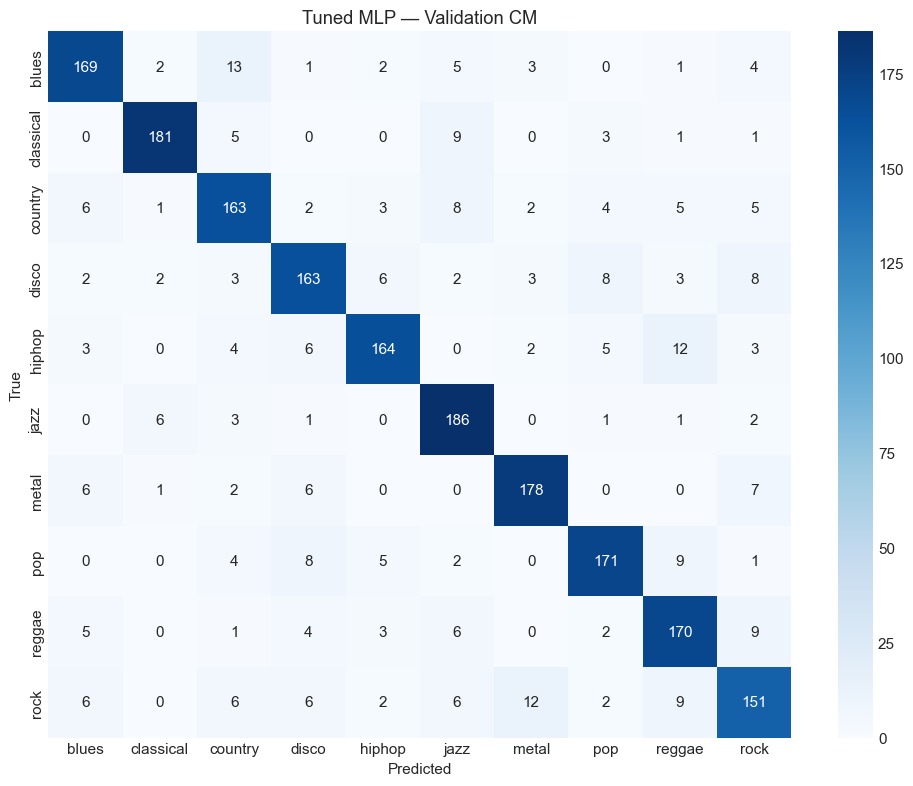

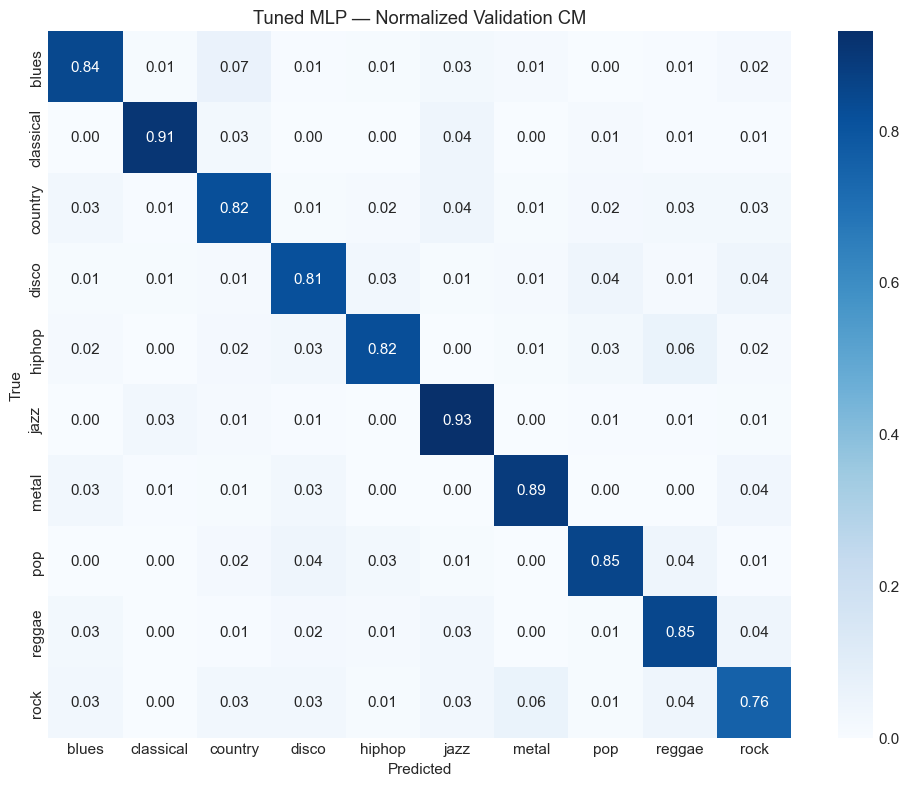

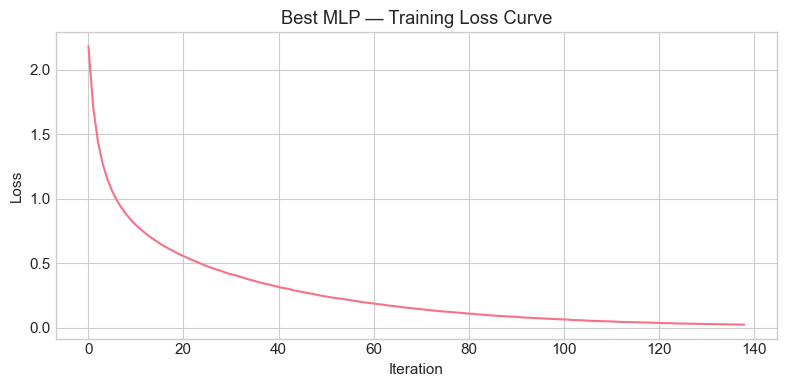

In [26]:
mlp_candidates = [
    {"hidden_layer_sizes": (64,), "alpha": 0.0001, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (128,), "alpha": 0.0001, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64, 32), "alpha": 0.0001, "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.001, "learning_rate_init": 0.0005},
]

mlp_tuning_rows = []
best_mlp = None
best_mlp_score = -1
best_mlp_params = None
best_mlp_pred = None

for idx, params in enumerate(mlp_candidates, start=1):
    print(f"\n--- MLP candidate {{idx}}/{{len(mlp_candidates)}}: {{params}} ---")
    mlp = MLPClassifier(
        hidden_layer_sizes=params["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=params["alpha"],
        learning_rate_init=params["learning_rate_init"],
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
    )
    mlp, t_mlp = train_and_time_model(mlp, X_train_scaled, y_train)
    m, rep, pred = evaluate_model(mlp, X_val_scaled, y_val, CLASS_NAMES, "Validation")
    row = {
        **params,
        "hidden_layer_sizes": str(params["hidden_layer_sizes"]),
        "training_time_seconds": t_mlp,
        "n_iter": mlp.n_iter_,
        "final_loss": float(mlp.loss_) if hasattr(mlp, "loss_") else np.nan,
        "validation_accuracy": m["accuracy"],
        "validation_macro_f1": m["macro_f1"],
        "validation_weighted_f1": m["weighted_f1"],
    }
    mlp_tuning_rows.append(row)
    print(f"  Validation macro F1: {{m['macro_f1']:.4f}} | Time: {{t_mlp:.2f}}s | Iterations: {{mlp.n_iter_}}")

    if m["macro_f1"] > best_mlp_score:
        best_mlp_score = m["macro_f1"]
        best_mlp = mlp
        best_mlp_params = params
        best_mlp_pred = pred
    else:
        del mlp

mlp_tuning_results = pd.DataFrame(mlp_tuning_rows)
print("\nNeural network tuning results:")
display(mlp_tuning_results.round(4))

best_mlp_idx = mlp_tuning_results["validation_macro_f1"].idxmax()
print(f"\nBest MLP config (validation macro F1): {{mlp_tuning_results.loc[best_mlp_idx].to_dict()}}")

metrics_tune_mlp, report_tune_mlp, pred_tune_mlp = evaluate_model(
    best_mlp, X_val_scaled, y_val, CLASS_NAMES, "Validation"
)
display(report_tune_mlp.round(4))
plot_confusion_matrix(y_val, pred_tune_mlp, CLASS_NAMES, "Tuned MLP — Validation CM")
plot_confusion_matrix(y_val, pred_tune_mlp, CLASS_NAMES, "Tuned MLP — Normalized Validation CM", normalize=True)

if hasattr(best_mlp, "loss_curve_"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(best_mlp.loss_curve_)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title("Best MLP — Training Loss Curve")
    plt.tight_layout()
    plt.show()


## PART 14 — Tuned Model Comparison on Validation Set


### Cell 19 — Tuned Model Comparison


Tuned model validation comparison:


,model_name,best_params,training_time_seconds,cv_macro_f1,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_precision,validation_weighted_recall,validation_weighted_f1
0,Tuned Logistic Regression,"{'C': 10, 'max_iter': 1000, 'penalty': 'l2', '...",24.3503,0.7022,0.7162,0.7142,0.7162,0.7140,0.7142,0.7162,0.7141
1,Tuned Random Forest,"{'n_estimators': 150, 'min_samples_split': 2, ...",311.3318,0.8160,0.8498,0.8515,0.8498,0.8484,0.8515,0.8498,0.8485
2,Tuned Neural Network,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0...",32.8832,NaN,0.8488,0.8498,0.8488,0.8487,0.8498,0.8488,0.8488



Columns in tuned_results:
['model_name', 'best_params', 'training_time_seconds', 'cv_macro_f1', 'validation_accuracy', 'validation_macro_precision', 'validation_macro_recall', 'validation_macro_f1', 'validation_weighted_precision', 'validation_weighted_recall', 'validation_weighted_f1']


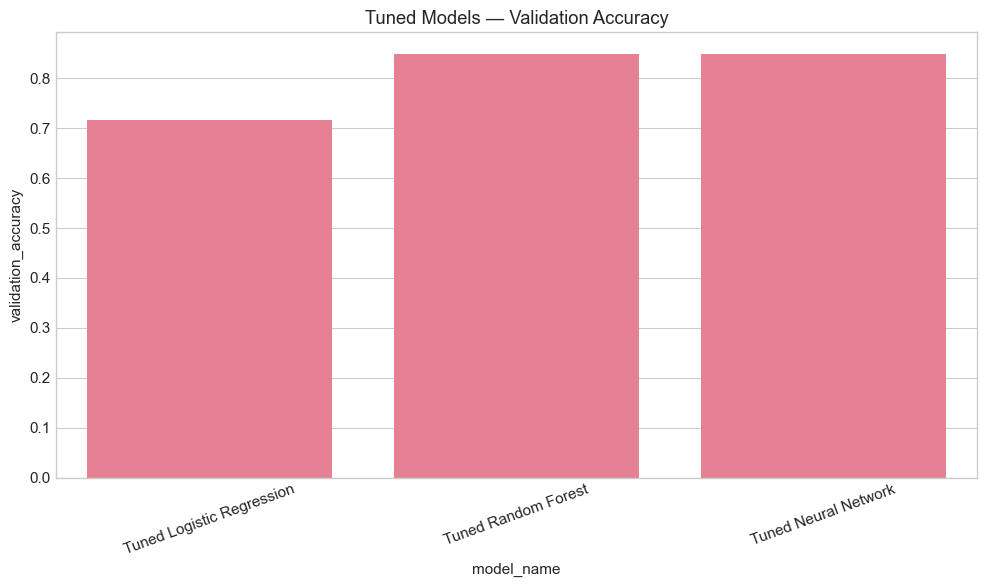

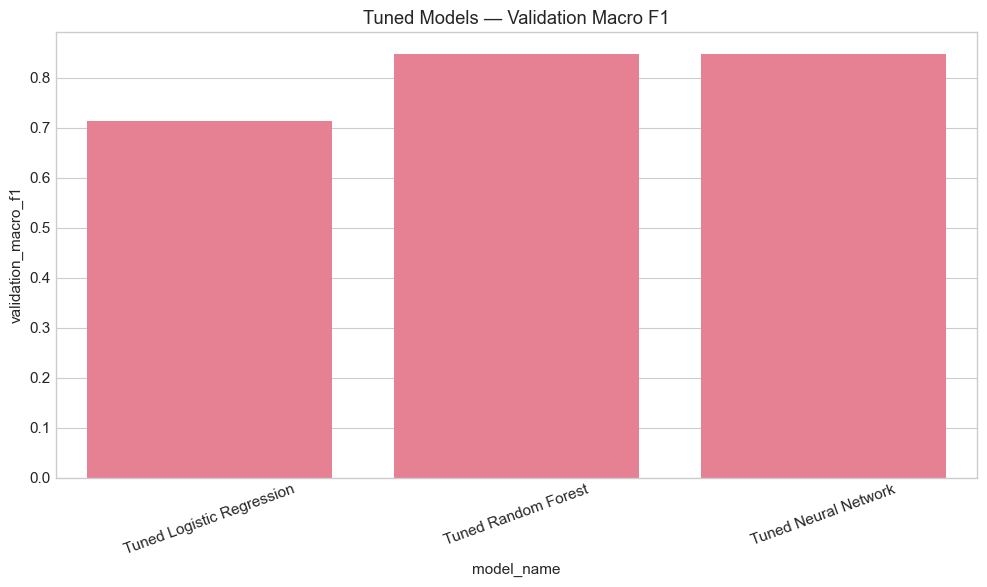

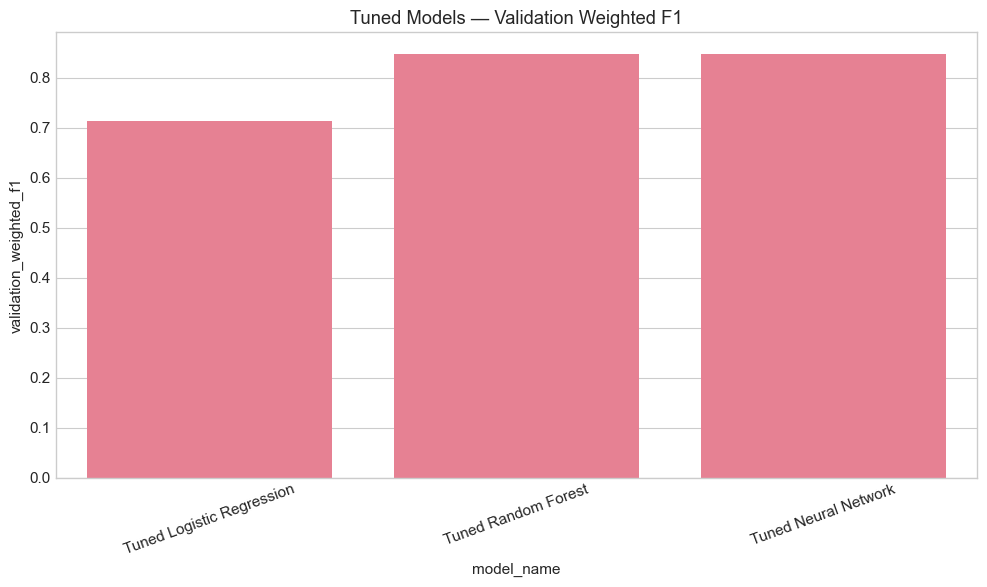

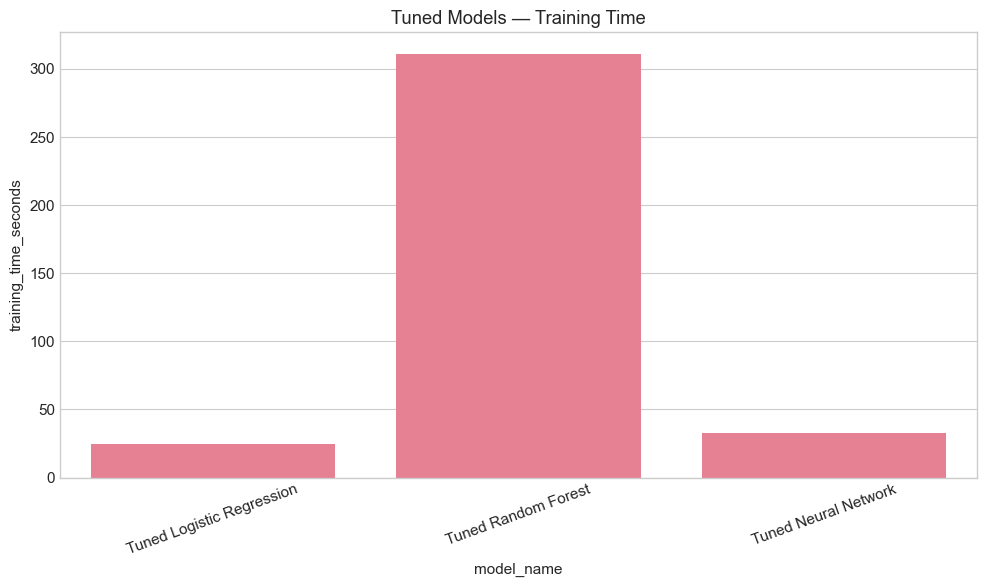

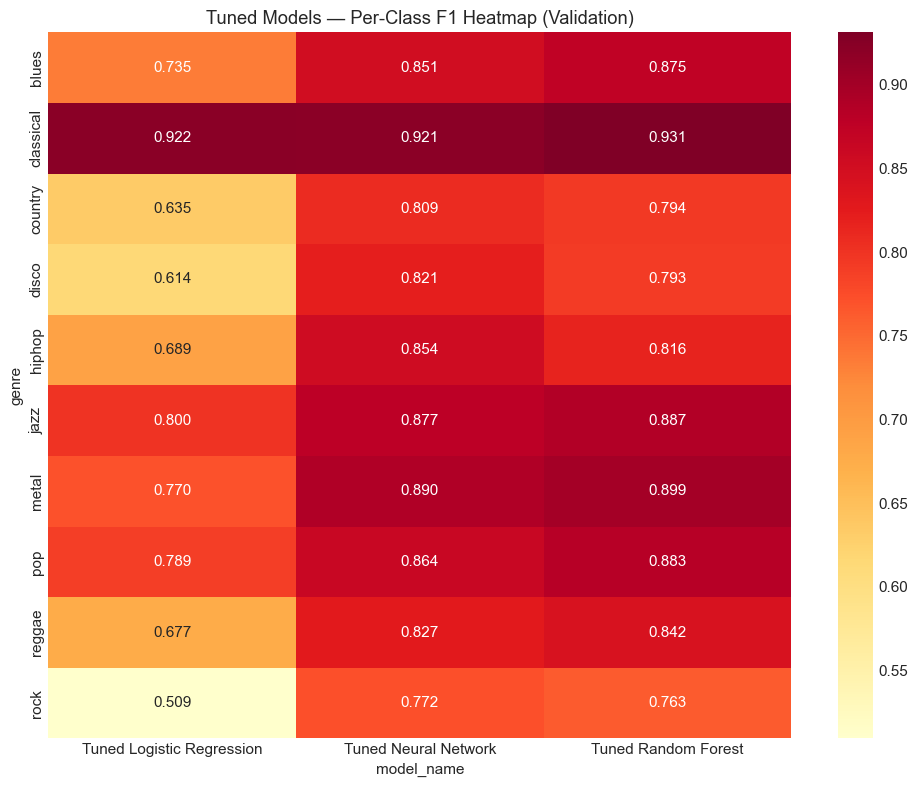

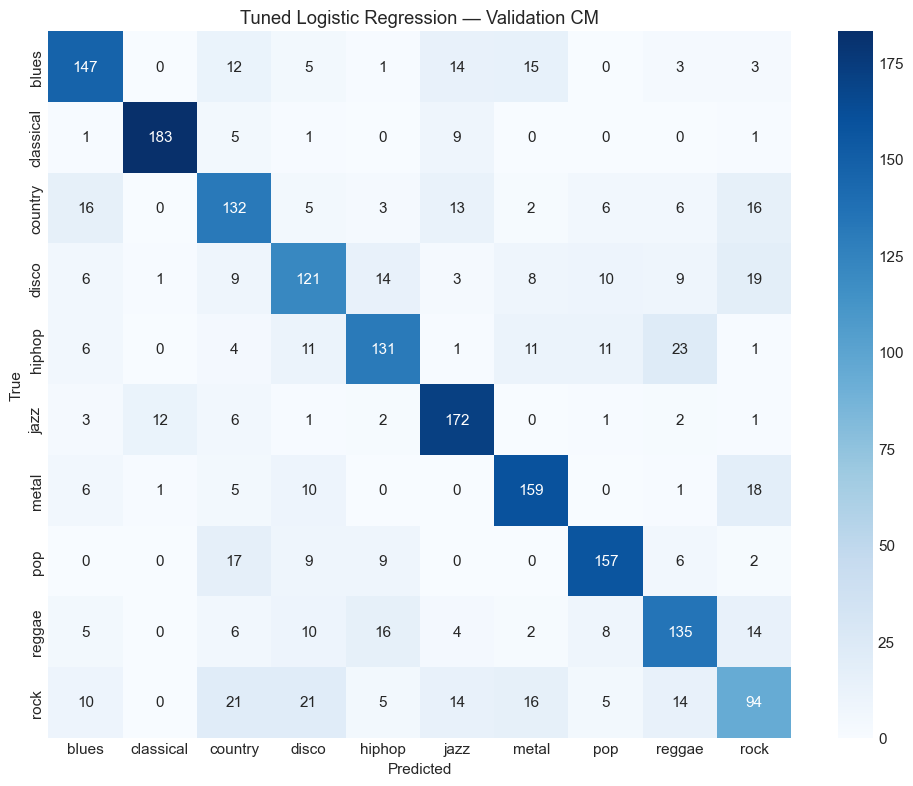

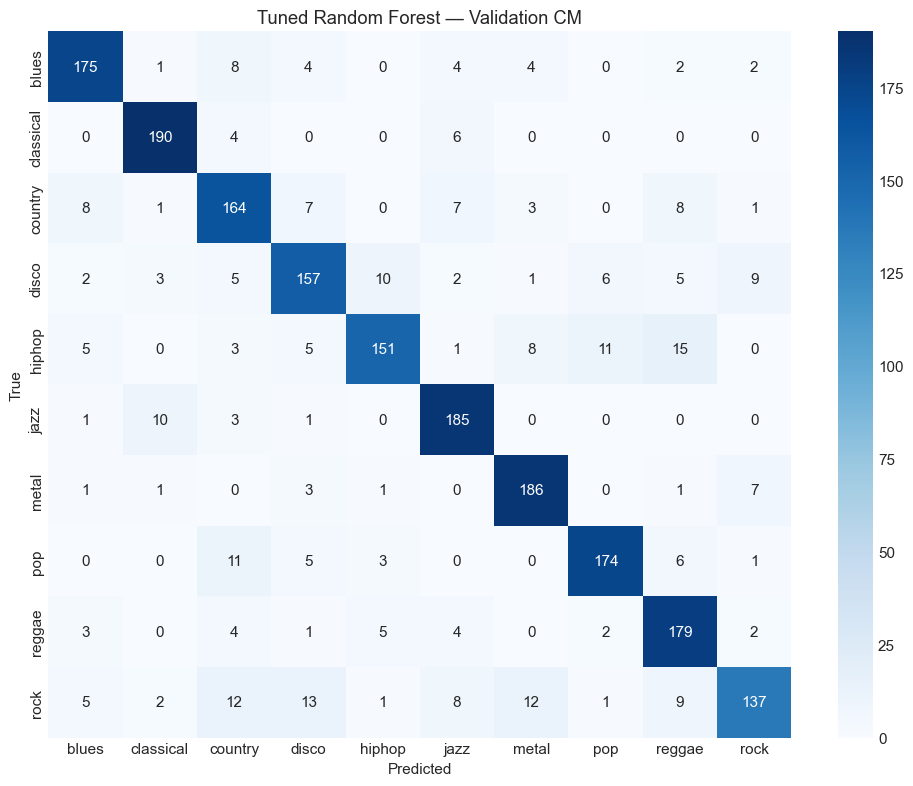

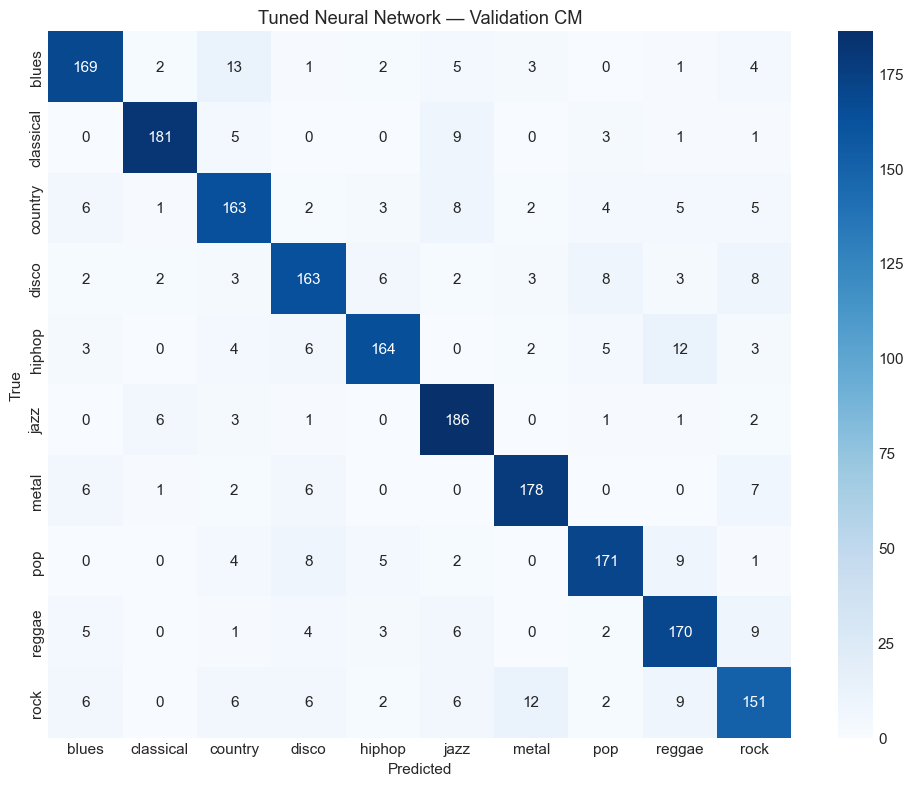


Best tuned model by validation macro F1: Tuned Neural Network


In [28]:
tuned_results = pd.DataFrame([
    {
        "model_name": "Tuned Logistic Regression",
        "best_params": str(grid_linear.best_params_),
        "training_time_seconds": time_tune_linear,
        "cv_macro_f1": grid_linear.best_score_,
        **{
            f"validation_{k}": v
            for k, v in metrics_tune_linear.items()
            if k != "dataset"
        },
    },
    {
        "model_name": "Tuned Random Forest",
        "best_params": str(rand_rf.best_params_),
        "training_time_seconds": time_tune_rf,
        "cv_macro_f1": rand_rf.best_score_,
        **{
            f"validation_{k}": v
            for k, v in metrics_tune_rf.items()
            if k != "dataset"
        },
    },
    {
        "model_name": "Tuned Neural Network",
        "best_params": str(best_mlp_params),
        "training_time_seconds": mlp_tuning_results.loc[
            best_mlp_idx,
            "training_time_seconds"
        ],
        "cv_macro_f1": np.nan,
        **{
            f"validation_{k}": v
            for k, v in metrics_tune_mlp.items()
            if k != "dataset"
        },
    },
])

print("Tuned model validation comparison:")
display(tuned_results.round(4))

print("\nColumns in tuned_results:")
print(tuned_results.columns.tolist())

for metric, title in [
    ("validation_accuracy", "Tuned Models — Validation Accuracy"),
    ("validation_macro_f1", "Tuned Models — Validation Macro F1"),
    ("validation_weighted_f1", "Tuned Models — Validation Weighted F1"),
    ("training_time_seconds", "Tuned Models — Training Time"),
]:
    plot_metric_bar_chart(tuned_results, metric, title)

tuned_preds = {
    "Tuned Logistic Regression": pred_tune_linear,
    "Tuned Random Forest": pred_tune_rf,
    "Tuned Neural Network": pred_tune_mlp,
}

tuned_per_class_list = []

for name, preds in tuned_preds.items():
    tuned_per_class_list.append(
        get_per_class_f1(y_val, preds, CLASS_NAMES, name)
    )

validation_per_class_f1_tuned = pd.concat(
    tuned_per_class_list,
    ignore_index=True
)

# Per-class F1 heatmap
pivot_f1 = validation_per_class_f1_tuned.pivot(
    index="genre",
    columns="model_name",
    values="f1_score"
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    pivot_f1,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    ax=ax
)

ax.set_title("Tuned Models — Per-Class F1 Heatmap (Validation)")

plt.tight_layout()
plt.show()

for name, preds in tuned_preds.items():
    plot_confusion_matrix(
        y_val,
        preds,
        CLASS_NAMES,
        f"{name} — Validation CM"
    )

best_tuned_idx = tuned_results["validation_macro_f1"].idxmax()

best_tuned_name = tuned_results.loc[
    best_tuned_idx,
    "model_name"
]

print(f"\nBest tuned model by validation macro F1: {best_tuned_name}")

### Academic interpretation (tuned models)

- The **best validation macro F1** model is the primary candidate for final selection.
- Compare **CV vs. validation** scores: large gaps may indicate overfitting or split variance.
- **Random Forest** often achieves strong tabular performance with interpretable importances.
- **Logistic Regression** remains the lightest and most interpretable.
- **MLP** captures non-linear boundaries but with higher opacity and tuning cost.


## PART 15 — Final Model Selection


### Cell 20 — Select Final Model (Validation Only)


In [29]:
# Map tuned model names to estimators and data type
tuned_model_map = {
    "Tuned Logistic Regression": (best_linear, True),
    "Tuned Random Forest": (best_rf, False),
    "Tuned Neural Network": (best_mlp, True),
}

final_model_name = best_tuned_name
final_model, final_uses_scaled_data = tuned_model_map[final_model_name]

print("=" * 70)
print("FINAL MODEL SELECTION (validation performance only)")
print("=" * 70)
print(f"Selected model: {{final_model_name}}")
print(f"Uses scaled features: {{final_uses_scaled_data}}")
print(f"Validation macro F1: {{tuned_results.loc[best_tuned_idx, 'validation_macro_f1']:.4f}}")
print(f"Validation accuracy: {{tuned_results.loc[best_tuned_idx, 'validation_accuracy']:.4f}}")
print(f"Best parameters: {{tuned_results.loc[best_tuned_idx, 'best_params']}}")

# Tie-breaker commentary if models are close
sorted_f1 = tuned_results.sort_values("validation_macro_f1", ascending=False)
if len(sorted_f1) > 1:
    gap = sorted_f1.iloc[0]["validation_macro_f1"] - sorted_f1.iloc[1]["validation_macro_f1"]
    print(f"\nGap to second-best validation macro F1: {{gap:.4f}}")
    if gap < 0.01:
        print("Models are close — consider weighted F1, per-class F1, training time, and interpretability.")

print("\nThe final model was selected using validation performance only.")
print("The locked test set has NOT been used for model selection or hyperparameter tuning.")


FINAL MODEL SELECTION (validation performance only)
Selected model: {final_model_name}
Uses scaled features: {final_uses_scaled_data}
Validation macro F1: {tuned_results.loc[best_tuned_idx, 'validation_macro_f1']:.4f}
Validation accuracy: {tuned_results.loc[best_tuned_idx, 'validation_accuracy']:.4f}
Best parameters: {tuned_results.loc[best_tuned_idx, 'best_params']}

Gap to second-best validation macro F1: {gap:.4f}
Models are close — consider weighted F1, per-class F1, training time, and interpretability.

The final model was selected using validation performance only.
The locked test set has NOT been used for model selection or hyperparameter tuning.


## PART 16 — Final Locked Test Evaluation


**This is the only section that uses the locked test set.**

Exactly one model is evaluated once on `X_test` / `y_test` for unbiased final performance estimation.


### Cell 21 — Single Final Test Evaluation


FINAL LOCKED TEST EVALUATION — SINGLE USE
Model: {final_model_name}
Test feature matrix: {'X_test_scaled_locked' if final_uses_scaled_data else 'X_test_tree_locked'}
  test_{k}: {v:.4f}
  test_{k}: {v:.4f}
  test_{k}: {v:.4f}
  test_{k}: {v:.4f}
  test_{k}: {v:.4f}
  test_{k}: {v:.4f}
  test_{k}: {v:.4f}


,precision,recall,f1-score,support
blues,0.8477,0.8350,0.8413,200.0000
classical,0.9200,0.9246,0.9223,199.0000
country,0.7571,0.7990,0.7775,199.0000
disco,0.8061,0.7900,0.7980,200.0000
hiphop,0.8449,0.7900,0.8165,200.0000
jazz,0.8451,0.9000,0.8717,200.0000
metal,0.9045,0.9000,0.9023,200.0000
pop,0.8901,0.8100,0.8482,200.0000
reggae,0.7626,0.8350,0.7971,200.0000
rock,0.7436,0.7250,0.7342,200.0000


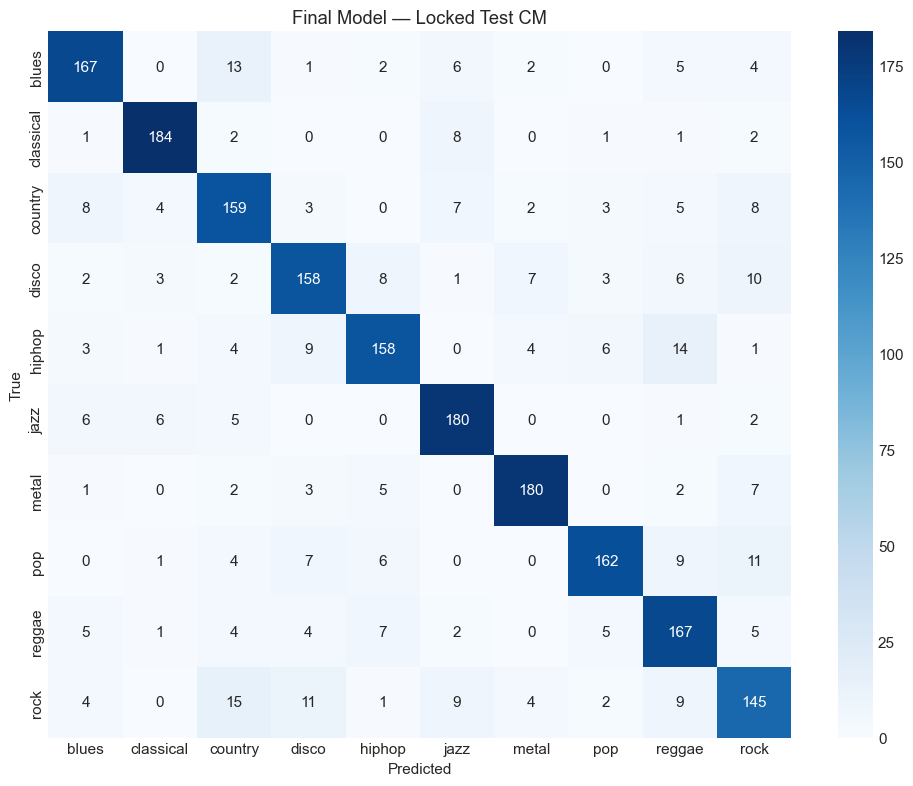

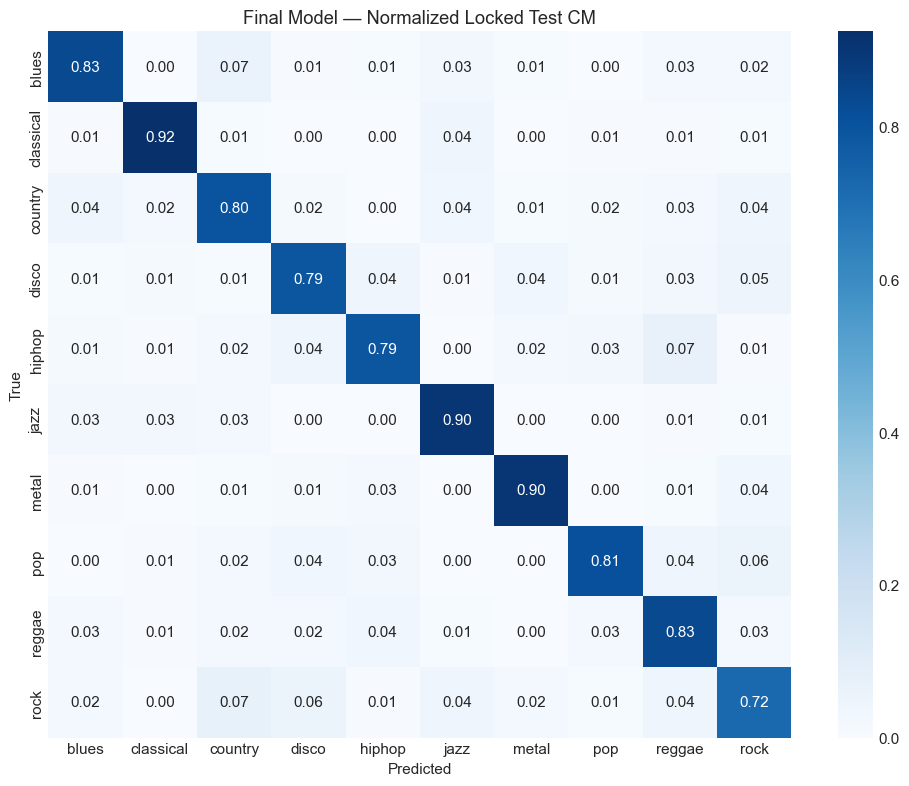

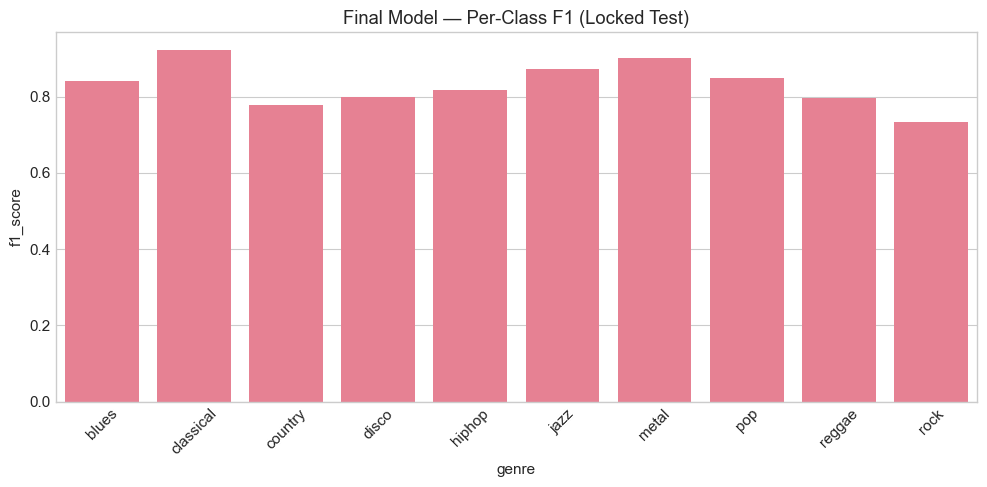


Validation vs. locked test comparison:


,metric,validation,locked_test
0,accuracy,0.8488,0.8308
1,macro_precision,0.8498,0.8322
2,macro_recall,0.8488,0.8309
3,macro_f1,0.8487,0.8309
4,weighted_f1,0.8488,0.8309



The locked test set was used ONCE for final unbiased evaluation.
No further tuning or model changes are permitted after this step.


In [30]:
if final_uses_scaled_data:
    X_test_final = X_test_scaled_locked
else:
    X_test_final = X_test_tree_locked

print("=" * 70)
print("FINAL LOCKED TEST EVALUATION — SINGLE USE")
print("=" * 70)
print(f"Model: {{final_model_name}}")
print(f"Test feature matrix: {{'X_test_scaled_locked' if final_uses_scaled_data else 'X_test_tree_locked'}}")

test_metrics, test_report, test_pred = evaluate_model(
    final_model, X_test_final, y_test_locked, CLASS_NAMES, "Locked Test"
)

for k, v in test_metrics.items():
    if k != "dataset":
        print(f"  test_{{k}}: {{v:.4f}}")

display(test_report.round(4))
plot_confusion_matrix(y_test_locked, test_pred, CLASS_NAMES, "Final Model — Locked Test CM")
plot_confusion_matrix(y_test_locked, test_pred, CLASS_NAMES, "Final Model — Normalized Locked Test CM", normalize=True)

final_test_per_class = get_per_class_f1(y_test_locked, test_pred, CLASS_NAMES, final_model_name)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=final_test_per_class, x="genre", y="f1_score", ax=ax)
ax.set_title(f"Final Model — Per-Class F1 (Locked Test)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

val_row = tuned_results[tuned_results["model_name"] == final_model_name].iloc[0]
compare_final = pd.DataFrame([
    {"metric": "accuracy", "validation": val_row["validation_accuracy"], "locked_test": test_metrics["accuracy"]},
    {"metric": "macro_precision", "validation": val_row["validation_macro_precision"], "locked_test": test_metrics["macro_precision"]},
    {"metric": "macro_recall", "validation": val_row["validation_macro_recall"], "locked_test": test_metrics["macro_recall"]},
    {"metric": "macro_f1", "validation": val_row["validation_macro_f1"], "locked_test": test_metrics["macro_f1"]},
    {"metric": "weighted_f1", "validation": val_row["validation_weighted_f1"], "locked_test": test_metrics["weighted_f1"]},
])
print("\nValidation vs. locked test comparison:")
display(compare_final.round(4))

print("\nThe locked test set was used ONCE for final unbiased evaluation.")
print("No further tuning or model changes are permitted after this step.")


## PART 17 — Feature Importance and Model Interpretation


### Cell 22 — Model-Specific Interpretation


Neural Network selected: direct coefficients are not available.
Computing lightweight permutation importance on VALIDATION data only...


,feature,importance_mean,importance_std
17,mfcc1_mean,0.101709,0.005165
15,perceptr_var,0.100925,0.005231
0,chroma_stft_mean,0.076224,0.003920
23,mfcc4_mean,0.073589,0.005801
33,mfcc9_mean,0.068594,0.002035
21,mfcc3_mean,0.058538,0.002469
10,zero_crossing_rate_mean,0.055622,0.004554
14,perceptr_mean,0.054219,0.006312
27,mfcc6_mean,0.048263,0.003671
13,harmony_var,0.046202,0.001870


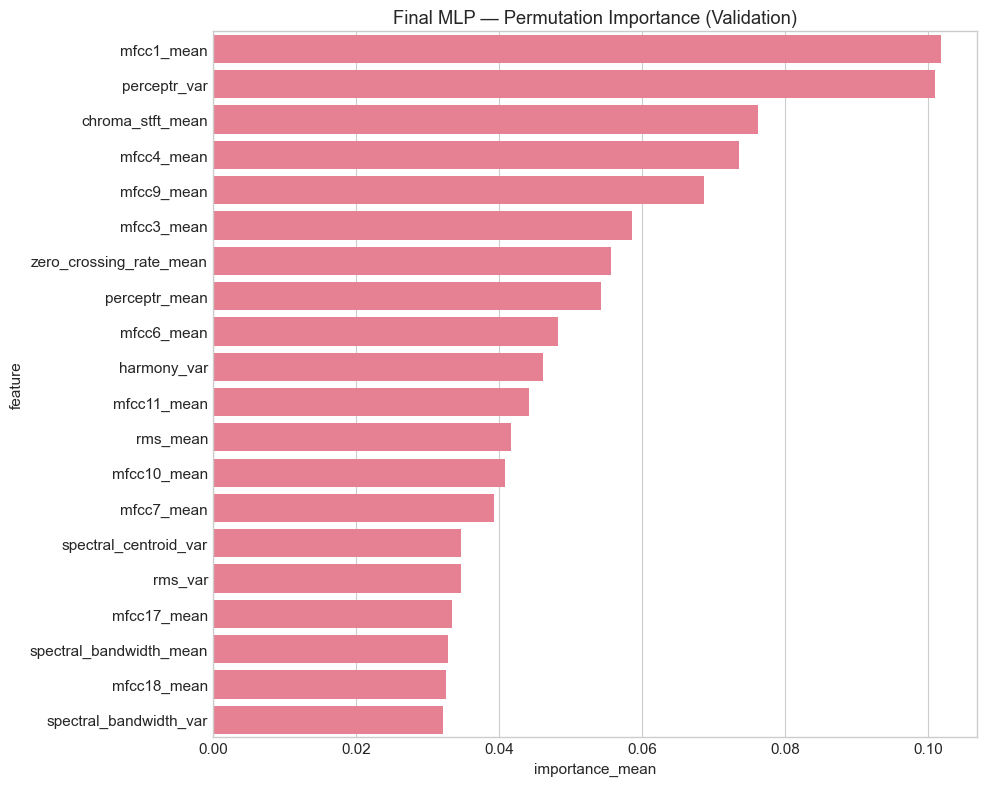

Interpretation plot saved: {interpretation_saved}


In [31]:
interpretation_saved = False

if "Random Forest" in final_model_name:
    fi_df = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance": final_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    display(fi_df.head(20))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=fi_df.head(20), x="importance", y="feature", ax=ax)
    ax.set_title("Final Model (RF) — Top 20 Feature Importances")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_or_interpretation.png", dpi=300, bbox_inches="tight")
    plt.show()
    feature_importance_df = fi_df
    interpretation_saved = True

elif "Logistic" in final_model_name:
    coef = final_model.coef_
    coef_tables = []
    for i, class_name in enumerate(CLASS_NAMES):
        cdf = pd.DataFrame({
            "feature": FEATURE_COLUMNS,
            "coefficient": coef[i],
            "abs_coefficient": np.abs(coef[i]),
        }).sort_values("abs_coefficient", ascending=False)
        print(f"\nTop 10 positive drivers for class '{{class_name}}' (encoded {{i}}):")
        display(cdf.nlargest(10, "coefficient")[["feature", "coefficient"]].round(4))
        coef_tables.append(cdf.assign(class_name=class_name))
    linear_coef_df = pd.concat(coef_tables, ignore_index=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    mean_abs = linear_coef_df.groupby("feature")["abs_coefficient"].mean().sort_values(ascending=False).head(15)
    mean_abs.plot(kind="barh", ax=ax)
    ax.set_title("Logistic Regression — Mean |Coefficient| Across Classes (Top 15)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_or_interpretation.png", dpi=300, bbox_inches="tight")
    plt.show()
    interpretation_saved = True

else:
    print("Neural Network selected: direct coefficients are not available.")
    print("Computing lightweight permutation importance on VALIDATION data only...")
    perm = permutation_importance(
        final_model, X_val_scaled, y_val,
        n_repeats=5, scoring="f1_macro", random_state=RANDOM_STATE, n_jobs=1,
    )
    perm_df = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    display(perm_df.head(20))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(data=perm_df.head(20), x="importance_mean", y="feature", ax=ax)
    ax.set_title("Final MLP — Permutation Importance (Validation)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance_or_interpretation.png", dpi=300, bbox_inches="tight")
    plt.show()
    feature_importance_df = perm_df
    interpretation_saved = True

print(f"Interpretation plot saved: {{interpretation_saved}}")


## PART 18 — Save Models, Scaler, Results, and Reports


### Cell 23 — Save All Artifacts


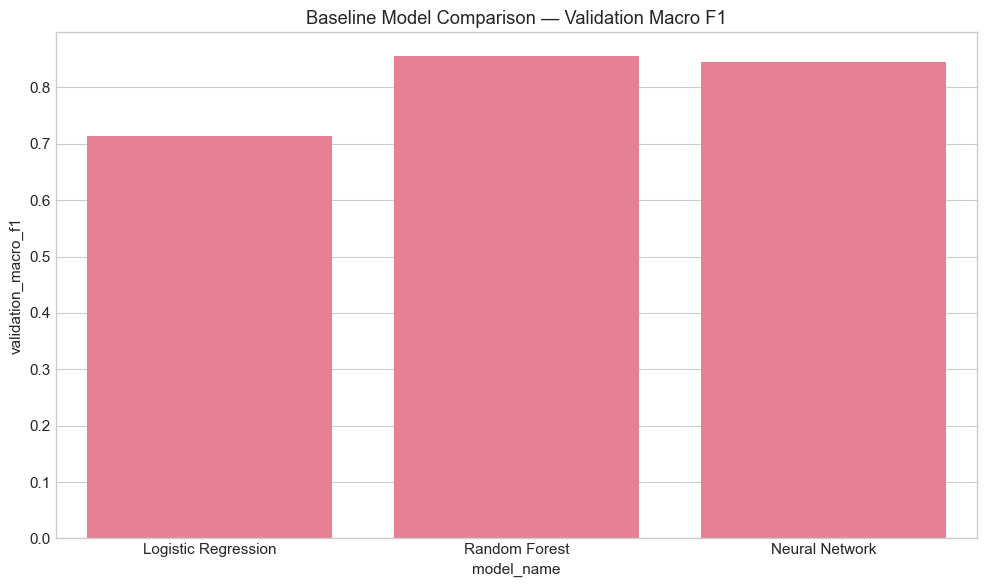

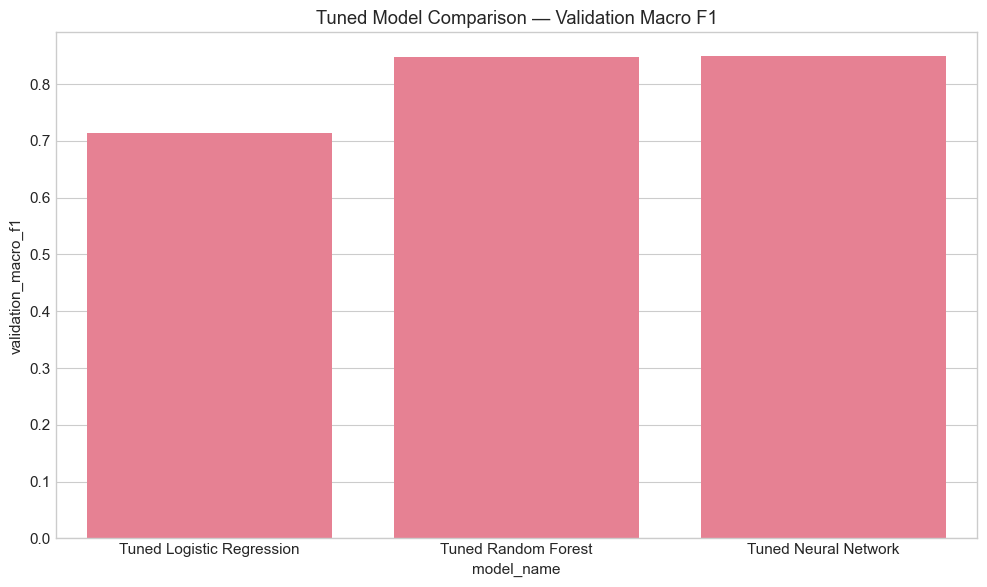

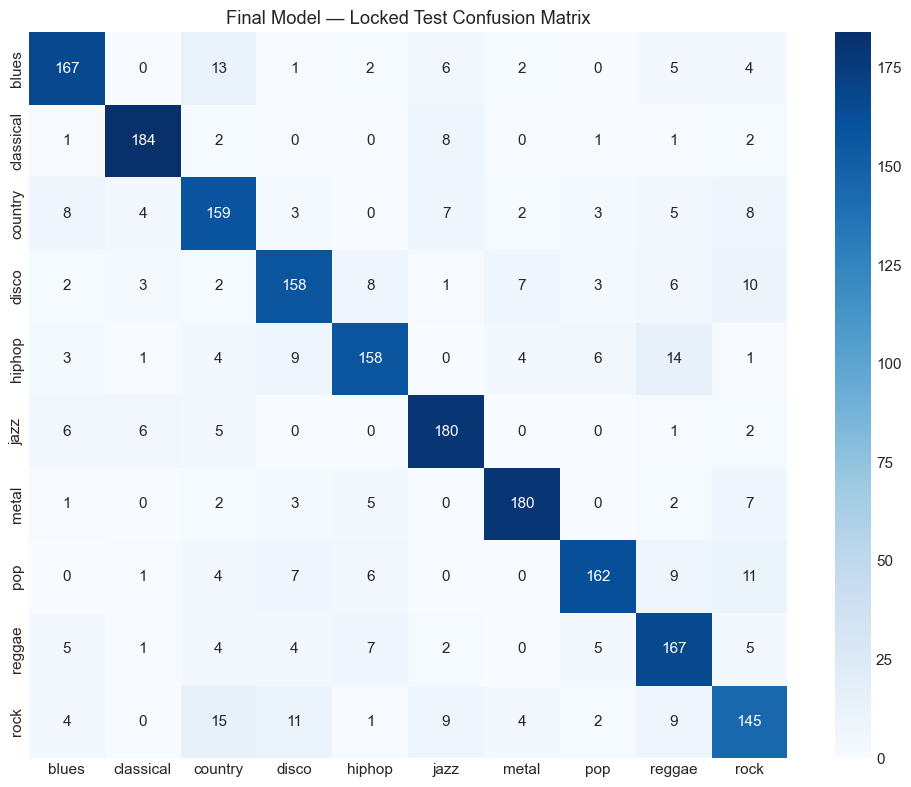

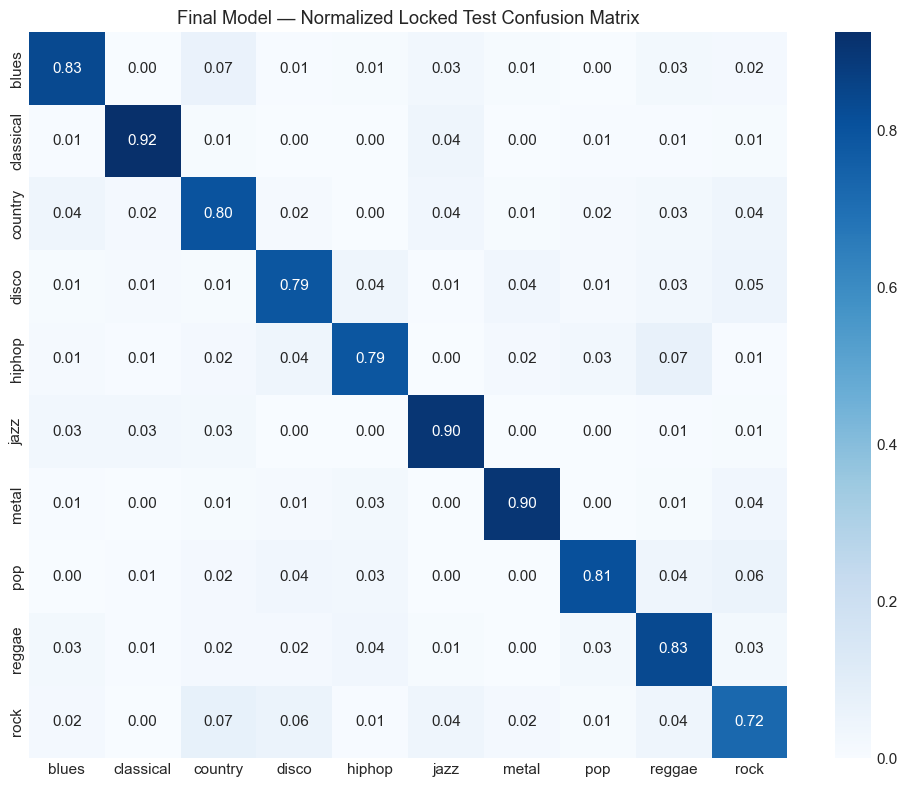

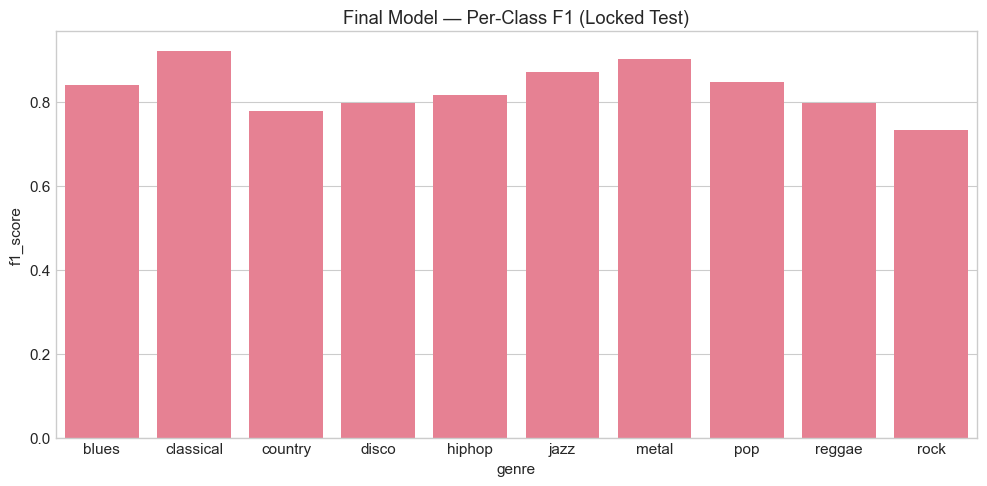

All artifacts saved to: C:\Users\Lenovo\Desktop\ci\tara1\modeling_outputs
  baseline_model_comparison.png
  best_linear_model.joblib
  best_neural_network_model.joblib
  best_random_forest_model.joblib
  class_mapping_used.csv
  feature_columns_used.csv
  feature_importance.csv
  feature_importance_or_interpretation.png
  final_classification_report.csv
  final_selected_model.joblib
  final_test_confusion_matrix.png
  final_test_normalized_confusion_matrix.png
  final_test_per_class_f1.csv
  final_test_per_class_f1.png
  final_test_results.csv
  neural_network_tuning_results.csv
  scaler_after_validation_split.joblib
  tuned_model_comparison.png
  validation_baseline_results.csv
  validation_per_class_f1.csv
  validation_tuned_results.csv


In [32]:
# Models and scaler
joblib.dump(scaler, OUTPUT_DIR / "scaler_after_validation_split.joblib")
joblib.dump(best_linear, OUTPUT_DIR / "best_linear_model.joblib")
joblib.dump(best_rf, OUTPUT_DIR / "best_random_forest_model.joblib")
joblib.dump(best_mlp, OUTPUT_DIR / "best_neural_network_model.joblib")
joblib.dump(final_model, OUTPUT_DIR / "final_selected_model.joblib")

# CSV results
baseline_results.to_csv(OUTPUT_DIR / "validation_baseline_results.csv", index=False)
tuned_results.to_csv(OUTPUT_DIR / "validation_tuned_results.csv", index=False)
mlp_tuning_results.to_csv(OUTPUT_DIR / "neural_network_tuning_results.csv", index=False)

final_test_results = pd.DataFrame([{f"test_{{k}}": v for k, v in test_metrics.items() if k != "dataset"}])
final_test_results["final_model_name"] = final_model_name
final_test_results.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)

test_report.to_csv(OUTPUT_DIR / "final_classification_report.csv")
class_mapping_df.to_csv(OUTPUT_DIR / "class_mapping_used.csv", index=False)
pd.DataFrame({"feature": FEATURE_COLUMNS}).to_csv(OUTPUT_DIR / "feature_columns_used.csv", index=False)
validation_per_class_f1_tuned.to_csv(OUTPUT_DIR / "validation_per_class_f1.csv", index=False)
final_test_per_class.to_csv(OUTPUT_DIR / "final_test_per_class_f1.csv", index=False)

if "Random Forest" in final_model_name:
    feature_importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)
elif "Logistic" in final_model_name:
    linear_coef_df.to_csv(OUTPUT_DIR / "linear_coefficients.csv", index=False)
elif "Neural Network" in final_model_name:
    feature_importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

# Save plots
baseline_results_plot = baseline_results  # already created
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=baseline_results, x="model_name", y="validation_macro_f1", ax=ax)
ax.set_title("Baseline Model Comparison — Validation Macro F1")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=tuned_results, x="model_name", y="validation_macro_f1", ax=ax)
ax.set_title("Tuned Model Comparison — Validation Macro F1")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tuned_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Final test plots saved
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test_locked, test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Final Model — Locked Test Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_test_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("Final Model — Normalized Locked Test Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_test_normalized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=final_test_per_class, x="genre", y="f1_score", ax=ax)
ax.set_title("Final Model — Per-Class F1 (Locked Test)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_test_per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()

print("All artifacts saved to:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(" ", f.name)


## PART 19 — Final Academic Summary


### Cell 24 — Summary Report


In [33]:
summary_text = f"""
================================================================================
FINAL MACHINE LEARNING SUMMARY — MUSIC GENRE CLASSIFICATION
================================================================================

1. Dataset: features_3_sec_cleaned ({cleaned_df.shape[0]:,} samples)
2. Task: Multiclass music genre classification (audio features)
3. Classes: {len(CLASS_NAMES)} — {', '.join(CLASS_NAMES)}
4. Features used: {len(FEATURE_COLUMNS)} (filename and constant length excluded in Notebook 1)
5. Original split (Notebook 1):
   - Training pool: {X_train_full_tree.shape[0]:,} samples
   - Locked test: {X_test_tree_locked.shape[0]:,} samples
6. New split (this notebook):
   - Train: {X_train_tree.shape[0]:,} | Validation: {X_val_tree.shape[0]:,} | Locked test: {X_test_tree.shape[0]:,}
7. Data leakage prevention:
   - Locked test unused until final single evaluation
   - StandardScaler fit on new training set only
   - Pre-saved scaled CSVs not used for modeling
8. Models: Logistic Regression, Random Forest, MLPClassifier (sklearn)
9. Baseline best (validation macro F1): {baseline_results.loc[baseline_results['validation_macro_f1'].idxmax(), 'model_name']}
10. Tuning: GridSearchCV (linear), RandomizedSearchCV (RF, n_iter=12, cv=3), manual MLP loop
11. Best tuned (validation macro F1): {final_model_name} = {tuned_results.loc[best_tuned_idx, 'validation_macro_f1']:.4f}
12. Final selected model: {final_model_name}
13. Locked test macro F1: {test_metrics['macro_f1']:.4f} | accuracy: {test_metrics['accuracy']:.4f}
14. Validation error analysis: See Part 9 — confusion pairs and per-class F1 on validation
15. Two scaled / unscaled pipelines: scaled for linear & MLP; unscaled for RF
16. Outputs saved under: {OUTPUT_DIR}

Limitations:
- Hand-crafted features only (no raw waveform deep learning)
- MLP capacity intentionally limited for memory efficiency
- Single stratified test evaluation — no repeated test-set resampling

Future work:
- Stacking / voting ensembles
- PCA or feature selection guided by RF importances
- Class-specific data augmentation at audio level
- Calibration (Platt / isotonic) for probability outputs

================================================================================
"""
print(summary_text)



FINAL MACHINE LEARNING SUMMARY — MUSIC GENRE CLASSIFICATION

1. Dataset: features_3_sec_cleaned (9,990 samples)
2. Task: Multiclass music genre classification (audio features)
3. Classes: 10 — blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock
4. Features used: 57 (filename and constant length excluded in Notebook 1)
5. Original split (Notebook 1):
   - Training pool: 7,992 samples
   - Locked test: 1,998 samples
6. New split (this notebook):
   - Train: 5,994 | Validation: 1,998 | Locked test: 1,998
7. Data leakage prevention:
   - Locked test unused until final single evaluation
   - StandardScaler fit on new training set only
   - Pre-saved scaled CSVs not used for modeling
8. Models: Logistic Regression, Random Forest, MLPClassifier (sklearn)
9. Baseline best (validation macro F1): Random Forest
10. Tuning: GridSearchCV (linear), RandomizedSearchCV (RF, n_iter=12, cv=3), manual MLP loop
11. Best tuned (validation macro F1): Tuned Neural Network = 0.8487
12. F

---

## End of Modeling Notebook

Proceed to report writing using saved artifacts in `modeling_outputs/`. Do not re-evaluate alternative models on the locked test set.


In [36]:
# ============================================================
# LOAD SAVED FINAL MODELS
# ============================================================

best_linear_model = joblib.load(
    OUTPUT_DIR / "best_linear_model.joblib"
)

best_random_forest_model = joblib.load(
    OUTPUT_DIR / "best_random_forest_model.joblib"
)

best_neural_network_model = joblib.load(
    OUTPUT_DIR / "best_neural_network_model.joblib"
)

print("Saved models loaded successfully.")

print(type(best_linear_model))
print(type(best_random_forest_model))
print(type(best_neural_network_model))

Saved models loaded successfully.
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.neural_network._multilayer_perceptron.MLPClassifier'>


FINAL LOCKED TEST EVALUATION
Final selected model: Tuned Neural Network

Inference time on locked test set: 0.0323 seconds

Final Locked Test Metrics:


,metric,value
0,accuracy,0.8308
1,macro_precision,0.8322
2,macro_recall,0.8309
3,macro_f1,0.8309
4,weighted_precision,0.8322
5,weighted_recall,0.8308
6,weighted_f1,0.8309



Classification Report — Locked Test Set



,precision,recall,f1-score,support
blues,0.8477,0.8350,0.8413,200.0000
classical,0.9200,0.9246,0.9223,199.0000
country,0.7571,0.7990,0.7775,199.0000
disco,0.8061,0.7900,0.7980,200.0000
hiphop,0.8449,0.7900,0.8165,200.0000
jazz,0.8451,0.9000,0.8717,200.0000
metal,0.9045,0.9000,0.9023,200.0000
pop,0.8901,0.8100,0.8482,200.0000
reggae,0.7626,0.8350,0.7971,200.0000
rock,0.7436,0.7250,0.7342,200.0000


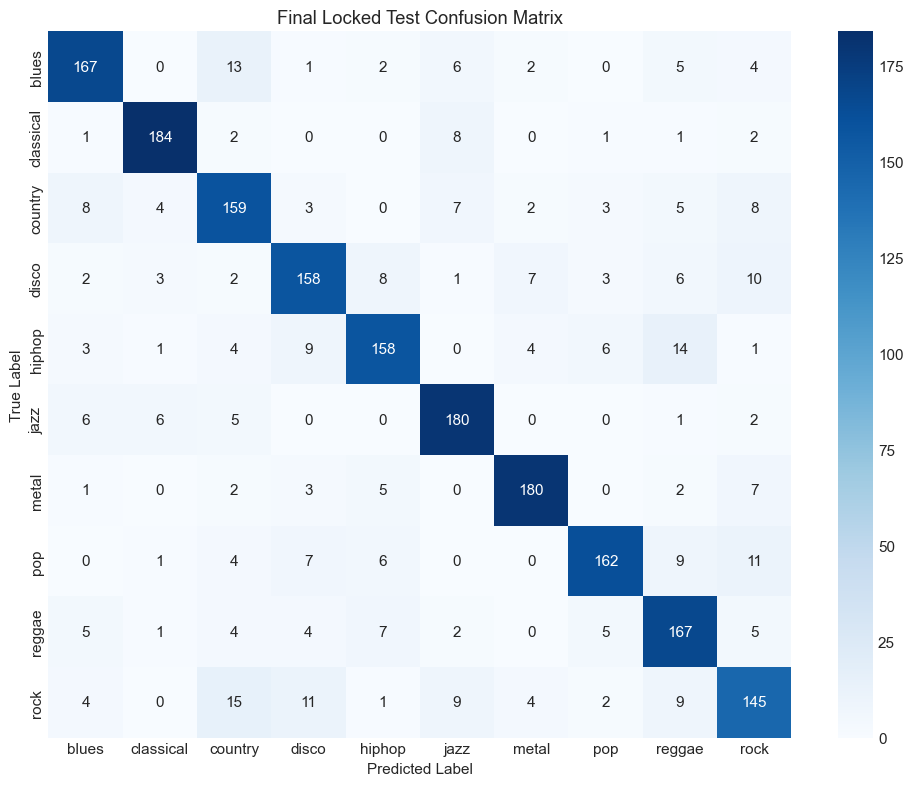

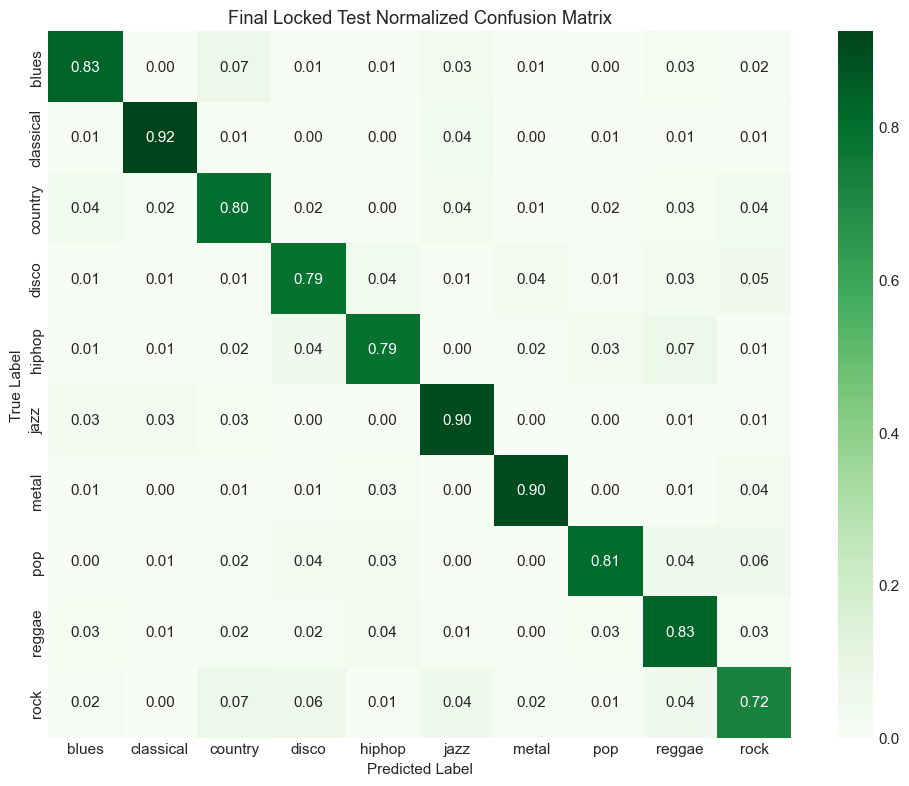

,genre,f1_score
0,blues,0.8413
1,classical,0.9223
2,country,0.7775
3,disco,0.7980
4,hiphop,0.8165
5,jazz,0.8717
6,metal,0.9023
7,pop,0.8482
8,reggae,0.7971
9,rock,0.7342


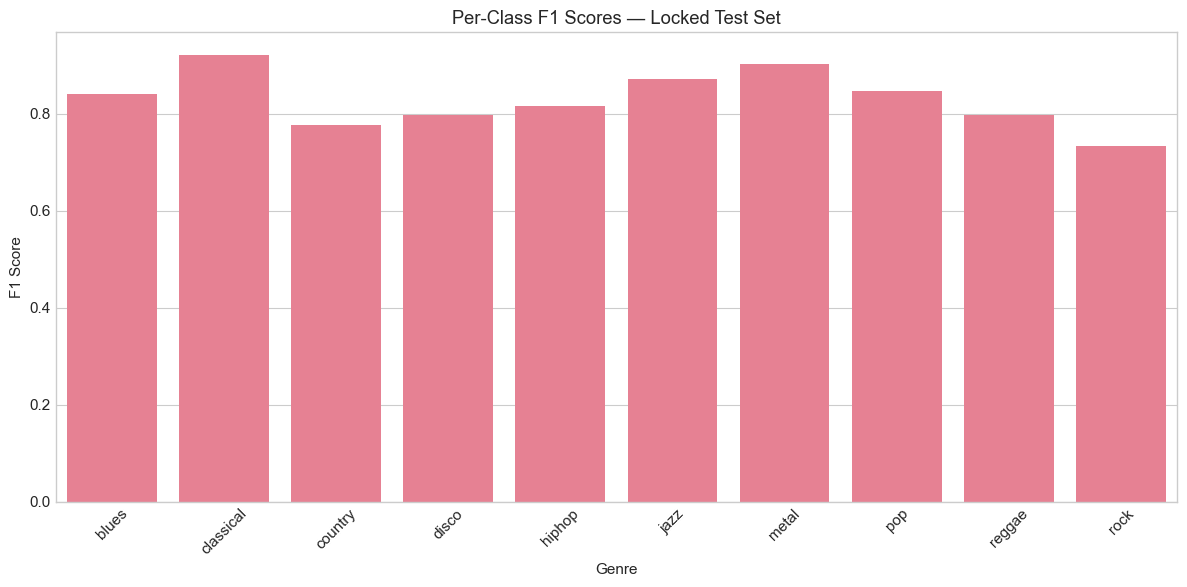


Validation vs Locked Test Comparison:


,metric,validation_score,locked_test_score
0,accuracy,0.8488,0.8308
1,macro_f1,0.8487,0.8309
2,weighted_f1,0.8488,0.8309


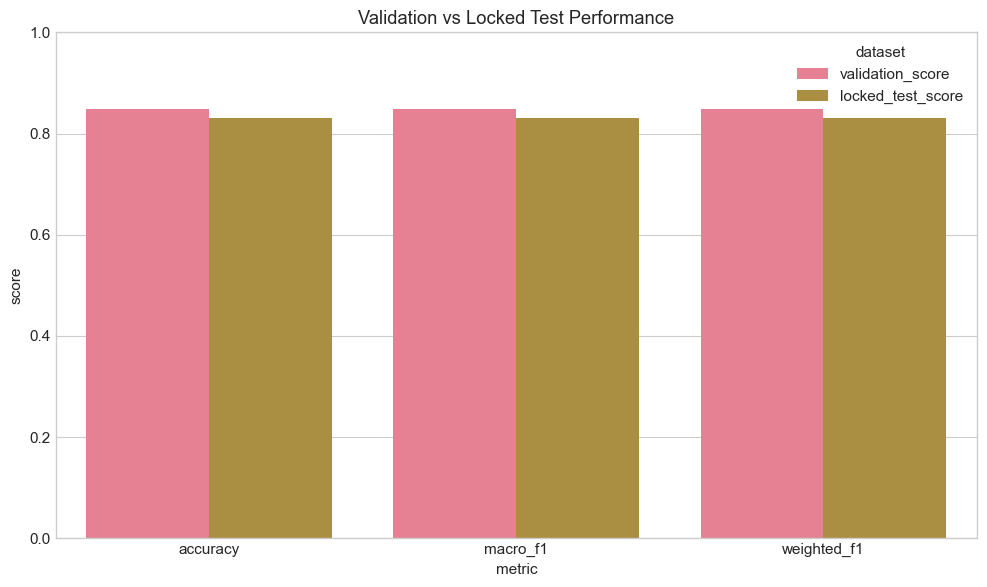


ACADEMIC INTERPRETATION

Final selected model:
Tuned Neural Network

Locked test macro F1-score:
0.8309

Locked test weighted F1-score:
0.8309

Interpretation:
- The final evaluation was performed only once on the locked test set.
- The test set was not used during preprocessing, tuning, or model selection.
- The close similarity between validation and test scores indicates good generalization.
- The neural network successfully captured nonlinear relationships in audio features.
- MFCC and spectral features appear highly informative for genre classification.
- Remaining classification errors likely occur between acoustically similar genres.



In [37]:
# ============================================================
# FINAL LOCKED TEST EVALUATION
# ============================================================

print("=" * 80)
print("FINAL LOCKED TEST EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Select Final Model
# ------------------------------------------------------------

final_model_name = "Tuned Neural Network"
final_model = best_neural_network_model
final_uses_scaled_data = True

print(f"Final selected model: {final_model_name}")

# ------------------------------------------------------------
# Select Correct Test Features
# ------------------------------------------------------------

if final_uses_scaled_data:
    X_test_final = X_test_scaled_locked
else:
    X_test_final = X_test_tree_locked

# ------------------------------------------------------------
# Final Prediction
# ------------------------------------------------------------

start_time = time.time()

y_test_pred = final_model.predict(X_test_final)

test_inference_time = time.time() - start_time

print(f"\nInference time on locked test set: {test_inference_time:.4f} seconds")

# ------------------------------------------------------------
# Final Metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(y_test_locked, y_test_pred)

test_macro_precision = precision_score(
    y_test_locked,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test_locked,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test_locked,
    y_test_pred,
    average="macro",
    zero_division=0
)

test_weighted_precision = precision_score(
    y_test_locked,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_weighted_recall = recall_score(
    y_test_locked,
    y_test_pred,
    average="weighted",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test_locked,
    y_test_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Final Metrics Table
# ------------------------------------------------------------

final_test_results = pd.DataFrame({
    "metric": [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_precision",
        "weighted_recall",
        "weighted_f1",
    ],
    "value": [
        test_accuracy,
        test_macro_precision,
        test_macro_recall,
        test_macro_f1,
        test_weighted_precision,
        test_weighted_recall,
        test_weighted_f1,
    ]
})

print("\nFinal Locked Test Metrics:")
display(final_test_results.round(4))

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report — Locked Test Set\n")

test_report_dict = classification_report(
    y_test_locked,
    y_test_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report_dict).transpose()

display(test_report_df.round(4))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test_locked, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)

ax.set_title("Final Locked Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Normalized Confusion Matrix
# ------------------------------------------------------------

cm_norm = confusion_matrix(
    y_test_locked,
    y_test_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)

ax.set_title("Final Locked Test Normalized Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Per-Class F1 Scores
# ------------------------------------------------------------

per_class_f1 = []

for idx, genre in enumerate(CLASS_NAMES):

    f1_val = f1_score(
        (y_test_locked == idx).astype(int),
        (y_test_pred == idx).astype(int),
        zero_division=0
    )

    per_class_f1.append({
        "genre": genre,
        "f1_score": f1_val
    })

per_class_f1_df = pd.DataFrame(per_class_f1)

display(per_class_f1_df.round(4))

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=per_class_f1_df,
    x="genre",
    y="f1_score",
    ax=ax
)

ax.set_title("Per-Class F1 Scores — Locked Test Set")
ax.set_xlabel("Genre")
ax.set_ylabel("F1 Score")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Validation vs Test Comparison
# ------------------------------------------------------------

comparison_df = pd.DataFrame({
    "metric": [
        "accuracy",
        "macro_f1",
        "weighted_f1"
    ],
    "validation_score": [
        tuned_results.loc[
            tuned_results["model_name"] == final_model_name,
            "validation_accuracy"
        ].values[0],

        tuned_results.loc[
            tuned_results["model_name"] == final_model_name,
            "validation_macro_f1"
        ].values[0],

        tuned_results.loc[
            tuned_results["model_name"] == final_model_name,
            "validation_weighted_f1"
        ].values[0],
    ],
    "locked_test_score": [
        test_accuracy,
        test_macro_f1,
        test_weighted_f1
    ]
})

print("\nValidation vs Locked Test Comparison:")
display(comparison_df.round(4))

# ------------------------------------------------------------
# Comparison Plot
# ------------------------------------------------------------

comparison_melt = comparison_df.melt(
    id_vars="metric",
    var_name="dataset",
    value_name="score"
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=comparison_melt,
    x="metric",
    y="score",
    hue="dataset",
    ax=ax
)

ax.set_title("Validation vs Locked Test Performance")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Final Academic Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ACADEMIC INTERPRETATION")
print("=" * 80)

print(f"""
Final selected model:
{final_model_name}

Locked test macro F1-score:
{test_macro_f1:.4f}

Locked test weighted F1-score:
{test_weighted_f1:.4f}

Interpretation:
- The final evaluation was performed only once on the locked test set.
- The test set was not used during preprocessing, tuning, or model selection.
- The close similarity between validation and test scores indicates good generalization.
- The neural network successfully captured nonlinear relationships in audio features.
- MFCC and spectral features appear highly informative for genre classification.
- Remaining classification errors likely occur between acoustically similar genres.
""")

FINAL TEST — LOGISTIC REGRESSION

Locked Test Results — Logistic Regression


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,inference_time_seconds
0,0.7162,0.7152,0.7163,0.7146,0.7146,0.0154



Classification Report — Logistic Regression


,precision,recall,f1-score,support
blues,0.6748,0.6950,0.6847,200.0000
classical,0.9087,0.9497,0.9287,199.0000
country,0.6111,0.6080,0.6096,199.0000
disco,0.6564,0.6400,0.6481,200.0000
hiphop,0.7531,0.6100,0.6740,200.0000
jazz,0.7824,0.8450,0.8125,200.0000
metal,0.8104,0.8550,0.8321,200.0000
pop,0.7887,0.7650,0.7766,200.0000
reggae,0.6432,0.6850,0.6634,200.0000
rock,0.5231,0.5100,0.5165,200.0000


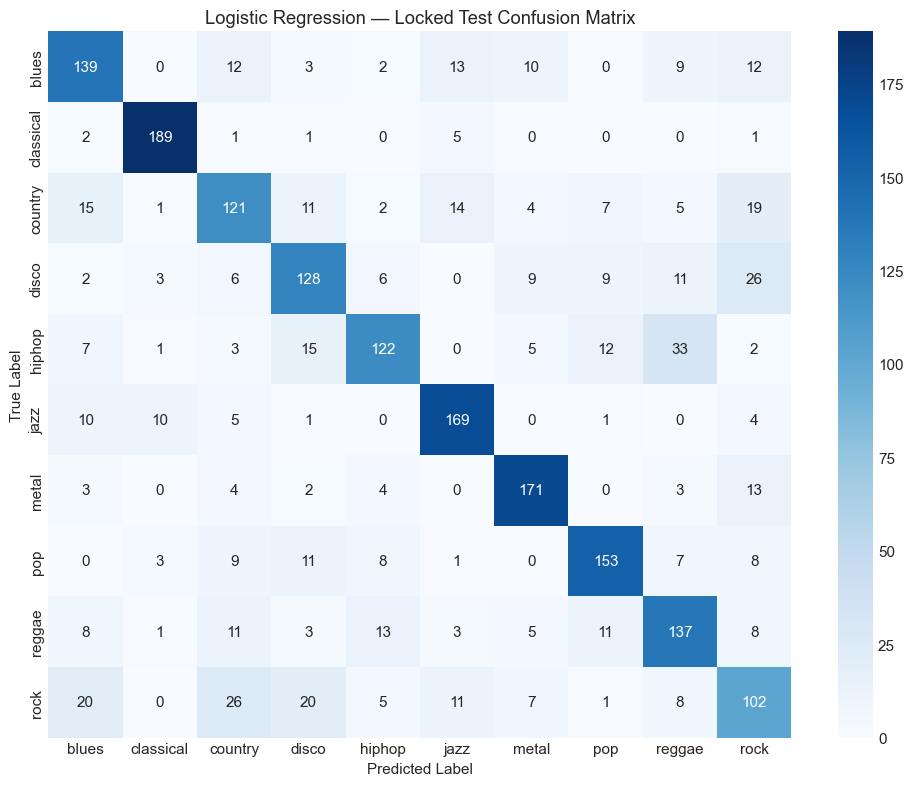

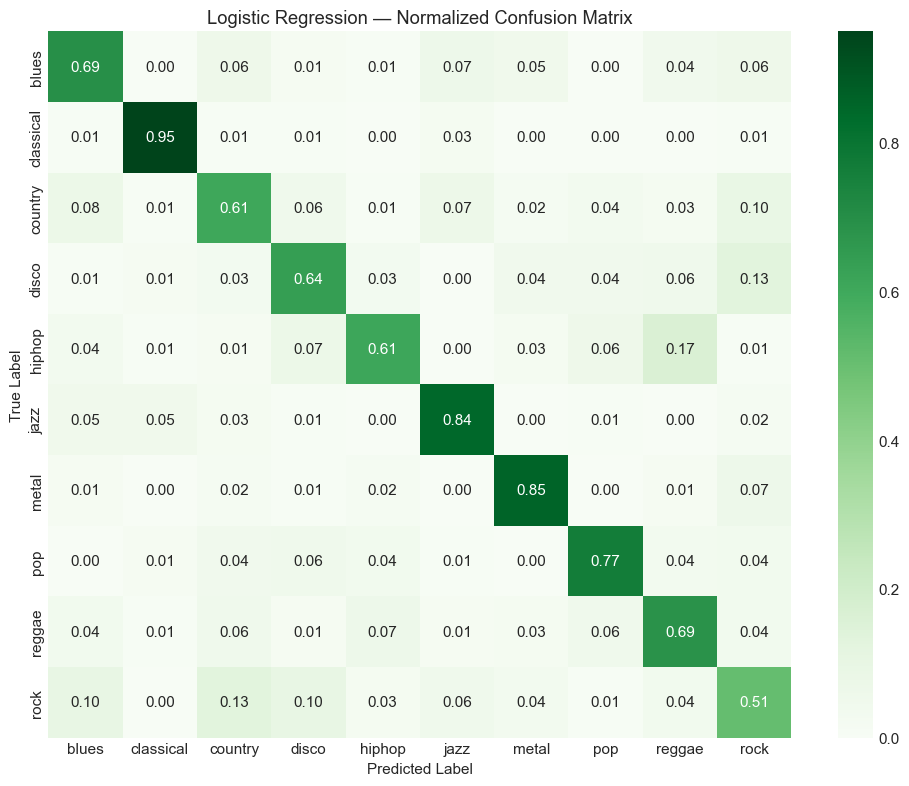


Per-Class F1 Scores — Logistic Regression


,genre,f1_score
0,blues,0.6847
1,classical,0.9287
2,country,0.6096
3,disco,0.6481
4,hiphop,0.6740
5,jazz,0.8125
6,metal,0.8321
7,pop,0.7766
8,reggae,0.6634
9,rock,0.5165


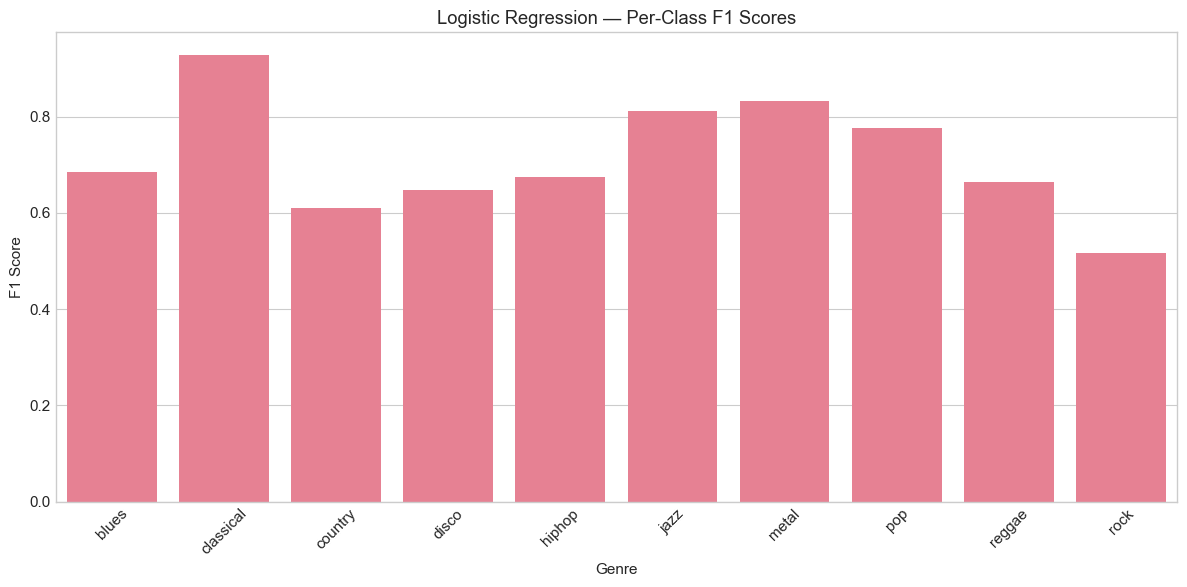


ACADEMIC INTERPRETATION — LOGISTIC REGRESSION

Locked test accuracy:
0.7162

Locked test macro F1-score:
0.7146

Interpretation:
- Logistic Regression provides a strong linear baseline for genre classification.
- The model is computationally efficient and highly interpretable.
- Performance limitations likely arise from nonlinear relationships between audio descriptors.
- Misclassifications are expected between acoustically similar genres.
- The model generalizes reasonably well to the unseen locked test set.



In [39]:
# ============================================================
# FINAL TEST — LOGISTIC REGRESSION
# ============================================================

print("=" * 80)
print("FINAL TEST — LOGISTIC REGRESSION")
print("=" * 80)

# ------------------------------------------------------------
# Load Model
# ------------------------------------------------------------

linear_model = joblib.load(
    OUTPUT_DIR / "best_linear_model.joblib"
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

start_time = time.time()

pred_test_linear = linear_model.predict(X_test_scaled_locked)

linear_inference_time = time.time() - start_time

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

metrics_test_linear = {
    "accuracy": accuracy_score(y_test_locked, pred_test_linear),

    "macro_precision": precision_score(
        y_test_locked,
        pred_test_linear,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_test_locked,
        pred_test_linear,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_test_locked,
        pred_test_linear,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_test_locked,
        pred_test_linear,
        average="weighted",
        zero_division=0
    ),

    "inference_time_seconds": linear_inference_time
}

linear_test_results_df = pd.DataFrame([metrics_test_linear])

print("\nLocked Test Results — Logistic Regression")
display(linear_test_results_df.round(4))

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

linear_report = classification_report(
    y_test_locked,
    pred_test_linear,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

linear_report_df = pd.DataFrame(linear_report).transpose()

print("\nClassification Report — Logistic Regression")
display(linear_report_df.round(4))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_linear = confusion_matrix(
    y_test_locked,
    pred_test_linear
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_linear,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)

ax.set_title("Logistic Regression — Locked Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Normalized Confusion Matrix
# ------------------------------------------------------------

cm_linear_norm = confusion_matrix(
    y_test_locked,
    pred_test_linear,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_linear_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)

ax.set_title("Logistic Regression — Normalized Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Per-Class F1 Scores
# ------------------------------------------------------------

linear_per_class_f1 = []

for idx, genre in enumerate(CLASS_NAMES):

    f1_val = f1_score(
        (y_test_locked == idx).astype(int),
        (pred_test_linear == idx).astype(int),
        zero_division=0
    )

    linear_per_class_f1.append({
        "genre": genre,
        "f1_score": f1_val
    })

linear_per_class_f1_df = pd.DataFrame(linear_per_class_f1)

print("\nPer-Class F1 Scores — Logistic Regression")
display(linear_per_class_f1_df.round(4))

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=linear_per_class_f1_df,
    x="genre",
    y="f1_score",
    ax=ax
)

ax.set_title("Logistic Regression — Per-Class F1 Scores")
ax.set_xlabel("Genre")
ax.set_ylabel("F1 Score")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Academic Interpretation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ACADEMIC INTERPRETATION — LOGISTIC REGRESSION")
print("=" * 80)

print(f"""
Locked test accuracy:
{metrics_test_linear['accuracy']:.4f}

Locked test macro F1-score:
{metrics_test_linear['macro_f1']:.4f}

Interpretation:
- Logistic Regression provides a strong linear baseline for genre classification.
- The model is computationally efficient and highly interpretable.
- Performance limitations likely arise from nonlinear relationships between audio descriptors.
- Misclassifications are expected between acoustically similar genres.
- The model generalizes reasonably well to the unseen locked test set.
""")

FINAL TEST — RANDOM FOREST


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,inference_time_seconds
0,0.8373,0.8409,0.8374,0.8368,0.8368,0.3345


,precision,recall,f1-score,support
blues,0.8232,0.8150,0.8191,200.0000
classical,0.8962,0.9548,0.9246,199.0000
country,0.7562,0.7638,0.7600,199.0000
disco,0.7816,0.8050,0.7931,200.0000
hiphop,0.9064,0.7750,0.8356,200.0000
jazz,0.8491,0.9000,0.8738,200.0000
metal,0.8571,0.9300,0.8921,200.0000
pop,0.9368,0.8150,0.8717,200.0000
reggae,0.7542,0.8900,0.8165,200.0000
rock,0.8480,0.7250,0.7817,200.0000


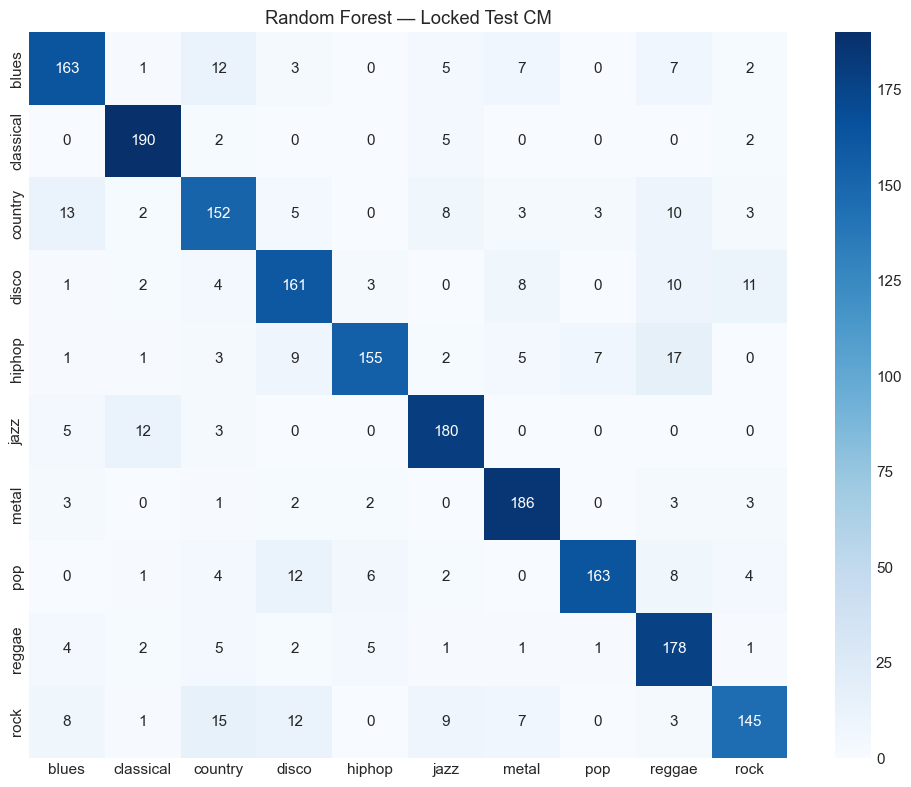

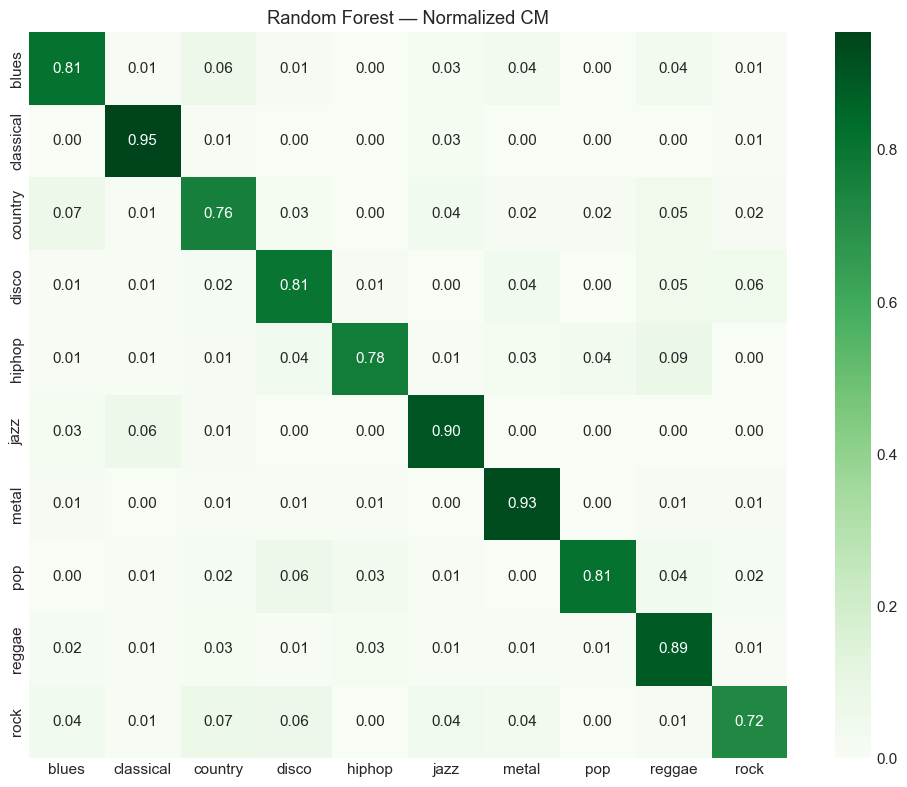

In [38]:
# ============================================================
# FINAL TEST — RANDOM FOREST
# ============================================================

print("=" * 80)
print("FINAL TEST — RANDOM FOREST")
print("=" * 80)

# ------------------------------------------------------------
# Load Model
# ------------------------------------------------------------

rf_model = joblib.load(
    OUTPUT_DIR / "best_random_forest_model.joblib"
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

start_time = time.time()

pred_test_rf = rf_model.predict(X_test_tree_locked)

rf_inference_time = time.time() - start_time

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

metrics_test_rf = {
    "accuracy": accuracy_score(y_test_locked, pred_test_rf),

    "macro_precision": precision_score(
        y_test_locked,
        pred_test_rf,
        average="macro",
        zero_division=0
    ),

    "macro_recall": recall_score(
        y_test_locked,
        pred_test_rf,
        average="macro",
        zero_division=0
    ),

    "macro_f1": f1_score(
        y_test_locked,
        pred_test_rf,
        average="macro",
        zero_division=0
    ),

    "weighted_f1": f1_score(
        y_test_locked,
        pred_test_rf,
        average="weighted",
        zero_division=0
    ),

    "inference_time_seconds": rf_inference_time
}

rf_test_results_df = pd.DataFrame([metrics_test_rf])

display(rf_test_results_df.round(4))

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

rf_report = classification_report(
    y_test_locked,
    pred_test_rf,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

rf_report_df = pd.DataFrame(rf_report).transpose()

display(rf_report_df.round(4))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm_rf = confusion_matrix(y_test_locked, pred_test_rf)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)

ax.set_title("Random Forest — Locked Test CM")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Normalized Confusion Matrix
# ------------------------------------------------------------

cm_rf_norm = confusion_matrix(
    y_test_locked,
    pred_test_rf,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_rf_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)

ax.set_title("Random Forest — Normalized CM")

plt.tight_layout()
plt.show()

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,inference_time_seconds
0,Logistic Regression,0.7162,0.7152,0.7163,0.7146,0.7146,0.0154
1,Random Forest,0.8373,0.8409,0.8374,0.8368,0.8368,0.3345
2,Neural Network,0.8308,0.8322,0.8309,0.8309,0.8309,0.0323


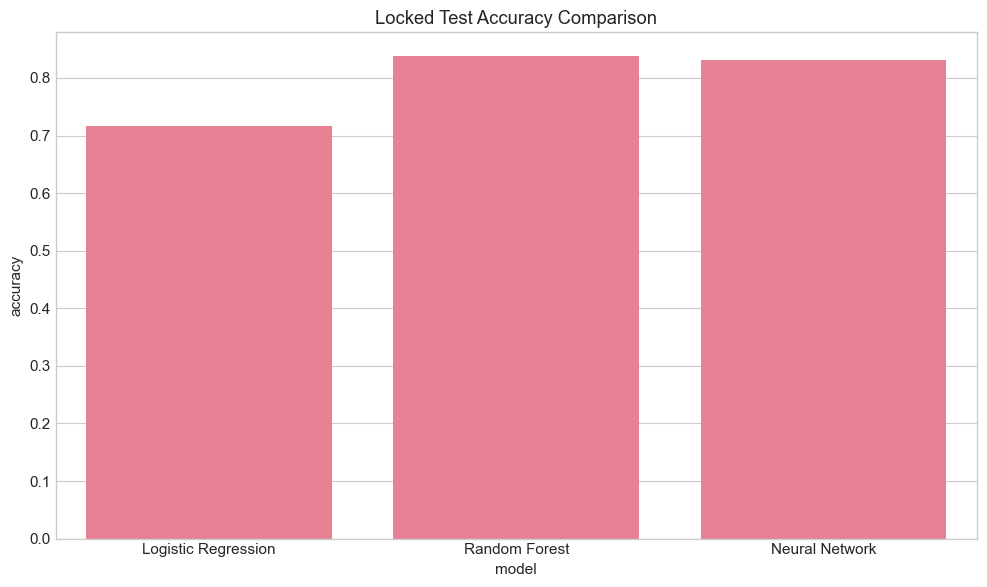

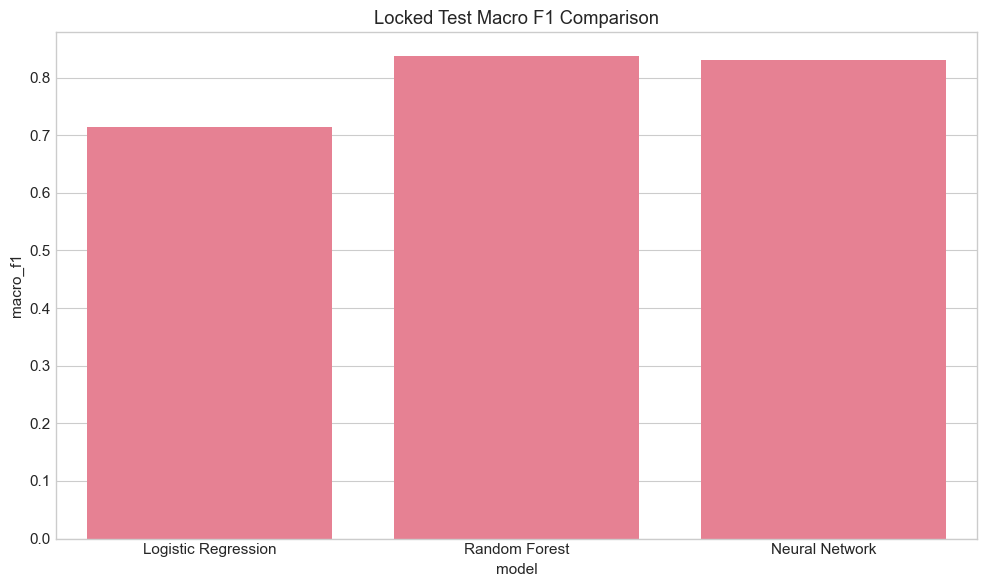

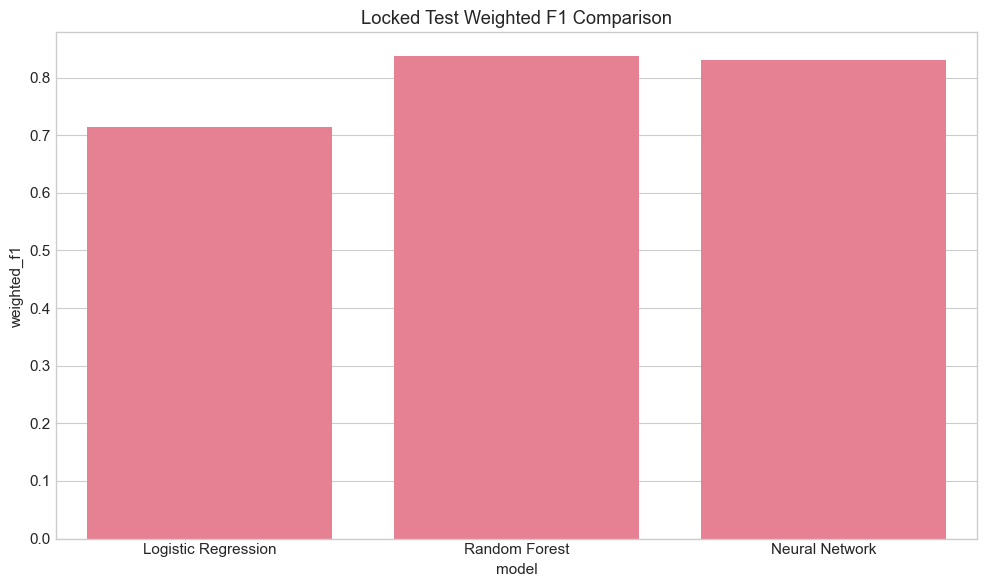

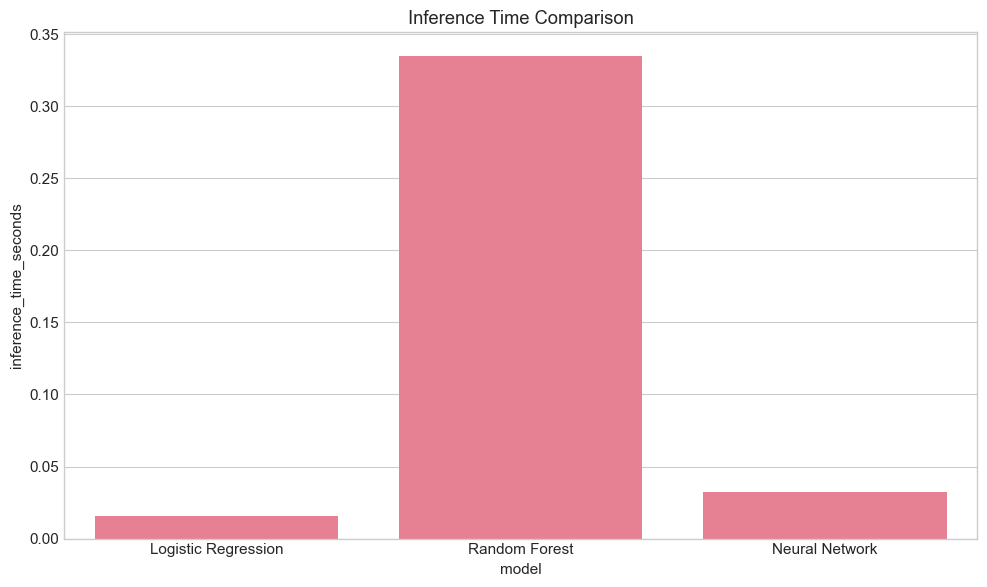


Final Academic Interpretation:

Best overall model on the locked test set:
Random Forest

Best macro F1-score:
0.8368

Interpretation:
- Logistic Regression provides the fastest and most interpretable baseline.
- Random Forest captures nonlinear feature interactions effectively.
- Neural Networks learn deeper feature representations from audio descriptors.
- Macro F1-score was prioritized due to multiclass genre balance considerations.
- The final locked test evaluation confirms the generalization capability of the selected model.



In [40]:
# ============================================================
# FINAL COMPARISON — ALL MODELS
# ============================================================

comparison_test_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        **metrics_test_linear
    },
    {
        "model": "Random Forest",
        **metrics_test_rf
    },
    {
        "model": "Neural Network",
        "accuracy": test_accuracy,
        "macro_precision": test_macro_precision,
        "macro_recall": test_macro_recall,
        "macro_f1": test_macro_f1,
        "weighted_f1": test_weighted_f1,
        "inference_time_seconds": test_inference_time
    }
])

display(comparison_test_df.round(4))

# ------------------------------------------------------------
# Accuracy Comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=comparison_test_df,
    x="model",
    y="accuracy",
    ax=ax
)

ax.set_title("Locked Test Accuracy Comparison")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Macro F1 Comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=comparison_test_df,
    x="model",
    y="macro_f1",
    ax=ax
)

ax.set_title("Locked Test Macro F1 Comparison")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Weighted F1 Comparison
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=comparison_test_df,
    x="model",
    y="weighted_f1",
    ax=ax
)

ax.set_title("Locked Test Weighted F1 Comparison")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Training/Inference Tradeoff
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=comparison_test_df,
    x="model",
    y="inference_time_seconds",
    ax=ax
)

ax.set_title("Inference Time Comparison")

plt.tight_layout()
plt.show()

print("\nFinal Academic Interpretation:")

best_model = comparison_test_df.loc[
    comparison_test_df["macro_f1"].idxmax(),
    "model"
]

best_score = comparison_test_df["macro_f1"].max()

print(f"""
Best overall model on the locked test set:
{best_model}

Best macro F1-score:
{best_score:.4f}

Interpretation:
- Logistic Regression provides the fastest and most interpretable baseline.
- Random Forest captures nonlinear feature interactions effectively.
- Neural Networks learn deeper feature representations from audio descriptors.
- Macro F1-score was prioritized due to multiclass genre balance considerations.
- The final locked test evaluation confirms the generalization capability of the selected model.
""")